# Bank Marketing — Term Deposit Subscription Prediction

Binary classification on a Portuguese bank's direct-marketing (phone-call)
campaign data: predict whether a client will subscribe to a **term deposit**
(`y = yes / no`). Knowing this in advance lets the bank prioritise calls,
cut costs, and raise conversion.

## Approach at a glance

- **EDA** — quality checks, per-feature analysis, and eight hypotheses about
  what drives subscription.
- **Preprocessing & feature engineering** — drop the leaky `duration` column,
  engineer `age_group` and `contacted_before`, ordinal-encode `education`,
  cap `campaign` outliers, and one-hot encode the rest. All fit-on-data steps
  are learned on the training split only (see the *data-leakage* note in §3).
- **Modelling** — Dummy baseline, Logistic Regression, kNN, Decision Tree,
  XGBoost, LightGBM.
- **Tuning** — LightGBM tuned with both RandomizedSearchCV and Hyperopt
  (Bayesian TPE).
- **Interpretation** — feature importance, SHAP, and an error analysis with
  concrete next steps.

**Primary metric: ROC-AUC** (ability to rank clients by subscription
probability), with **F1** as a secondary, imbalance-aware metric. Accuracy is
rejected because the classes are heavily imbalanced (≈88.7% `no` / 11.3% `yes`),
so an always-`no` model would already score ~88.7%.

## Dataset

Portuguese bank direct-marketing dataset (Moro et al.), sourced from
[Kaggle](https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv)
as `bank-additional-full.csv`: 41,176 rows after de-duplication, 20 input
features + 1 target.

### Feature description

**Client profile**
1. **age** — client age (numeric).
2. **job** — type of job (categorical).
3. **marital** — marital status (`divorced` also covers widowed).
4. **education** — education level (categorical).
5. **default** — has credit in default? (`no` / `yes` / `unknown`).
6. **housing** — has a housing loan? (`no` / `yes` / `unknown`).
7. **loan** — has a personal loan? (`no` / `yes` / `unknown`).

**Last contact of the current campaign**
8. **contact** — contact type (`cellular` / `telephone`).
9. **month** — last-contact month (`jan` … `dec`).
10. **day_of_week** — last-contact day of week (`mon` … `fri`).
11. **duration** — last-contact duration in seconds (numeric). ⚠ Highly
    predictive but known only *after* the call ends (and after `y` is
    effectively known), so it is used only for model comparison and **excluded**
    from the final model — direct target leakage.

**Other attributes**
12. **campaign** — number of contacts during this campaign for this client.
13. **pdays** — days since the client was last contacted in a previous campaign
    (`999` = not previously contacted).
14. **previous** — number of contacts before this campaign.
15. **poutcome** — outcome of the previous campaign (`failure` / `nonexistent` / `success`).

**Social & economic context**
16. **emp.var.rate** — employment variation rate (quarterly).
17. **cons.price.idx** — consumer price index (monthly).
18. **cons.conf.idx** — consumer confidence index (monthly).
19. **euribor3m** — 3-month Euribor rate (daily).
20. **nr.employed** — number of employees (quarterly).

**Target**
21. **y** — did the client subscribe to a term deposit? (`yes` / `no`).

## Project structure

- `Bank_Marketing_Term_Deposit_Prediction.ipynb` — this notebook (full analysis).
- `process_bank_marketing.py` — preprocessing pipeline (`engineer_features`,
  `prepare_train_val`).
- `utils.py` — reusable EDA helpers.
- `bank-additional-full.csv` — dataset.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, f1_score, recall_score, precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
import lightgbm as lgb
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import shap

from utils import (value_counts_of_column, describe_columns_summary,
                   calculate_iqr_bounds, analyze_numeric_vs_target,
                   analyze_categorical_vs_target)

from process_bank_marketing import engineer_features, prepare_train_val

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

---
## 1. Exploratory Data Analysis

Get to know the data, check quality, analyse each feature, and form hypotheses.


### 1.1 Loading and data-quality checks

In [3]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print('Shape (initial):', df.shape)
df.head()

Shape (initial): (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# describe_columns_summary: quick overview of dtypes, unique values, examples
describe_columns_summary(df)

column               | dtype      | unique | missing | examples
-----------------------------------------------------------------------------------------------
age                  | int64      |     78 |       0 | [56, 57, 37, 40, 45]
job                  | object     |     12 |       0 | [housemaid, services, admin., blue-collar, technician]
marital              | object     |      4 |       0 | [married, single, divorced, unknown]
education            | object     |      8 |       0 | [basic.4y, high.school, basic.6y, basic.9y, professional.course]
default              | object     |      3 |       0 | [no, unknown, yes]
housing              | object     |      3 |       0 | [no, yes, unknown]
loan                 | object     |      3 |       0 | [no, yes, unknown]
contact              | object     |      2 |       0 | [telephone, cellular]
month                | object     |     10 |       0 | [may, jun, jul, aug, oct]
day_of_week          | object     |      5 |       0 | [mon, t

In [5]:
# Check for and remove duplicates
dupes = df.duplicated().sum()
print(f'Duplicates: {dupes}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after removing duplicates: {df.shape}')

Duplicates: 12
Shape after removing duplicates: (41176, 21)


**Observation:** There are no explicit missing values, but several categorical features contain an `unknown` value — these are de-facto missing entries. We keep them as their own category so the model can use that fact.

### 1.2 Target variable

In [6]:
value_counts_of_column(df, 'y', n=2)

______Value counts for column 'y'______

Top 2 values:

Value           |      Count |  Percent
------------------------------------------
no              |      36537 |   88.73%
yes             |       4639 |   11.27%



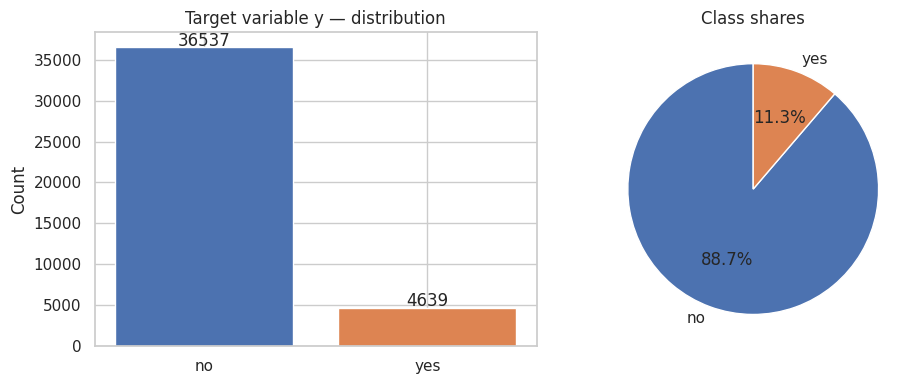

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df['y'].value_counts()

axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Target variable y — distribution')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class shares')

plt.tight_layout()
plt.show()

**Observation:** strong imbalance (88.7% vs 11.3%). Accuracy is not a suitable metric here.

### 1.3 Numeric features

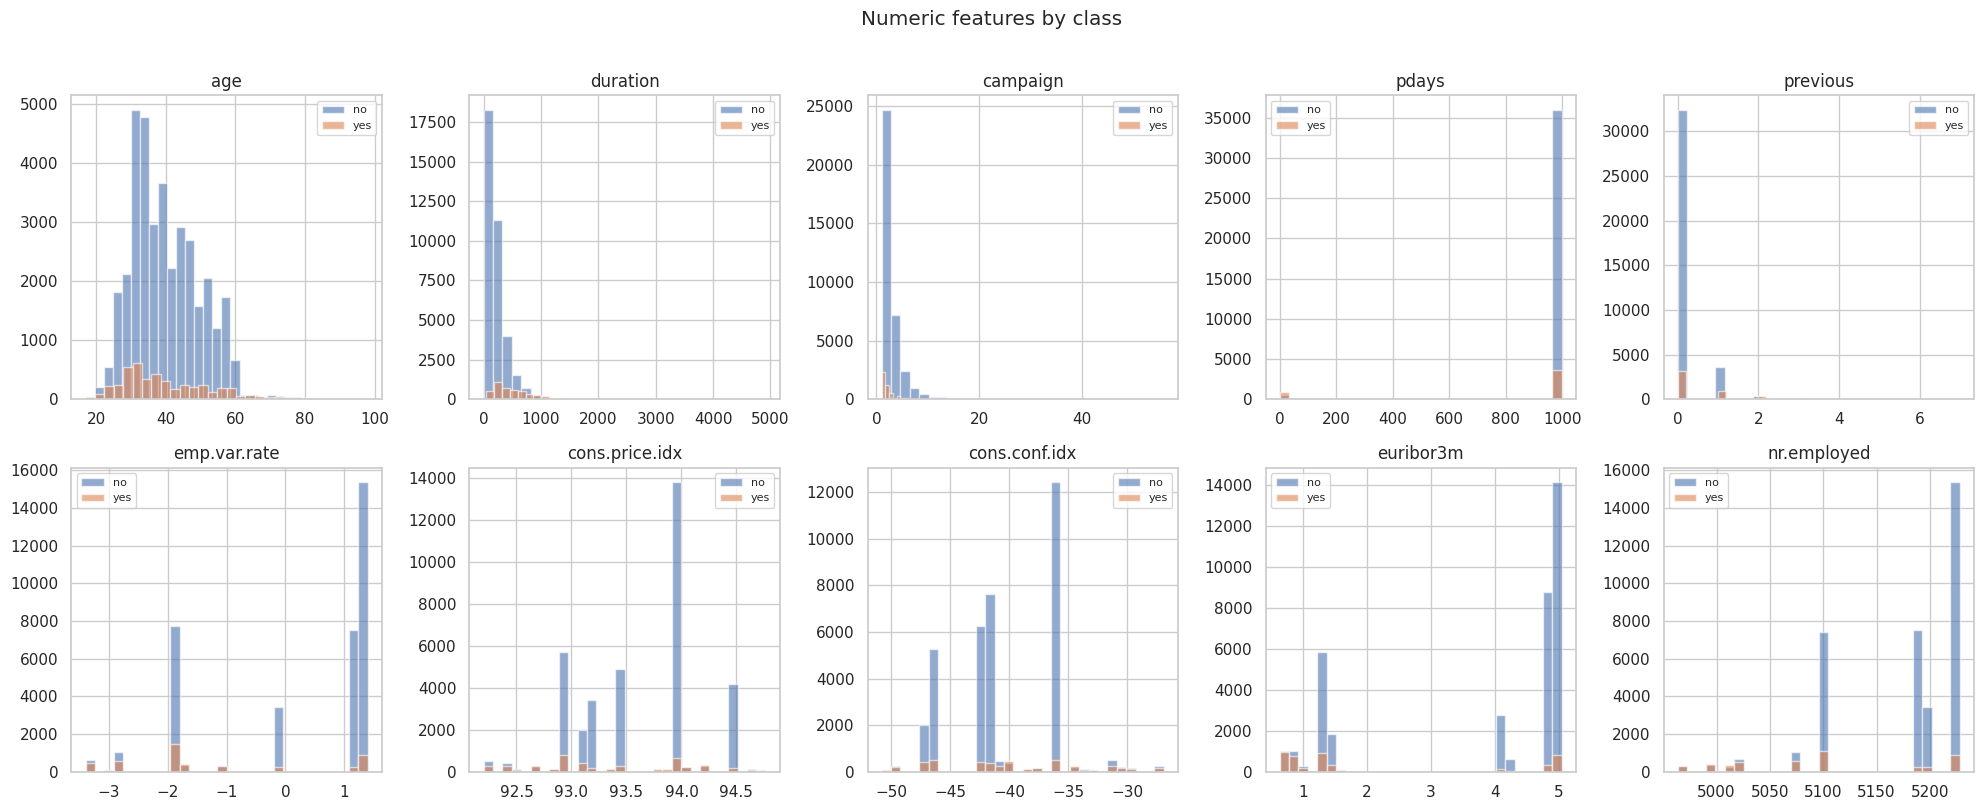

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, col in zip(axes.flat, num_cols):
    df[df['y']=='no'][col].hist(ax=ax, alpha=0.6, label='no', bins=30, color='#4C72B0')
    df[df['y']=='yes'][col].hist(ax=ax, alpha=0.6, label='yes', bins=30, color='#DD8452')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Numeric features by class', y=1.01)
plt.tight_layout()
plt.show()

Correlation of each numeric feature with the target is the basis for choosing which columns to analyse in detail.

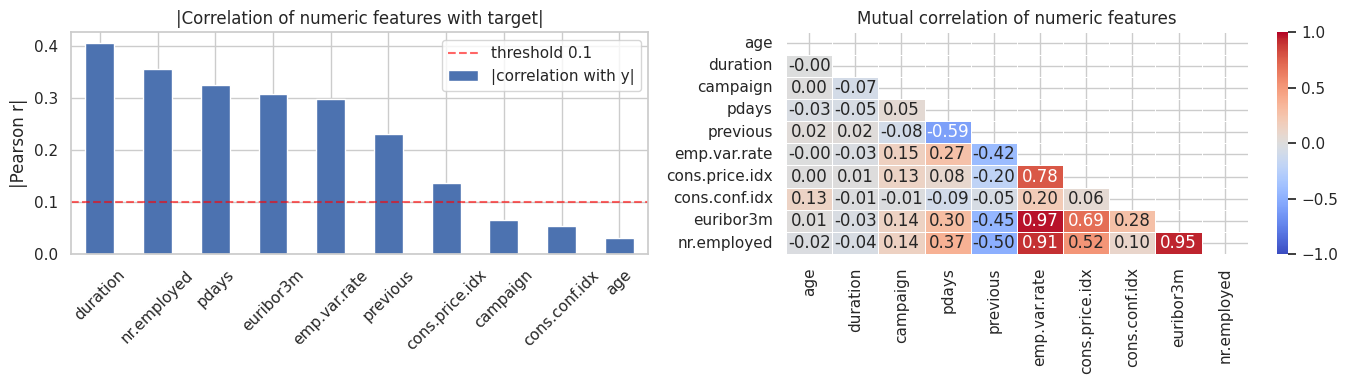

duration          0.405297
nr.employed       0.354669
pdays             0.324948
euribor3m         0.307740
emp.var.rate      0.298289
previous          0.230202
cons.price.idx    0.136134
campaign          0.066361
cons.conf.idx     0.054802
age               0.030381


In [9]:
y_num = (df['y'] == 'yes').astype(int)
corr_with_target = (
    df[num_cols]
    .corrwith(y_num)
    .abs()
    .sort_values(ascending=False)
    .rename('|correlation with y|')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: absolute correlation with the target
corr_with_target.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].axhline(0.1, color='red', linestyle='--', alpha=0.6, label='threshold 0.1')
axes[0].set_title('|Correlation of numeric features with target|')
axes[0].set_ylabel('|Pearson r|')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Heatmap: mutual correlation of numeric features (multicollinearity)
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.4, ax=axes[1])
axes[1].set_title('Mutual correlation of numeric features')

plt.tight_layout()
plt.show()

print(corr_with_target.to_string())

**Takeaways from the correlation analysis:**

**Strong correlation with the target (|r| > 0.1):**
- `euribor3m`, `emp.var.rate`, `nr.employed` — the three strongest predictors, but
  they correlate with each other at r > 0.9 (multicollinearity). One representative
  is enough for detailed analysis — we pick `euribor3m` because it is daily (more
  unique values) and has the highest correlation with the target.
- `campaign` — negative correlation: more calls → fewer conversions. It also has
  notable outliers worth a closer look.

**Weak correlation (|r| < 0.1):**
- `cons.price.idx`, `cons.conf.idx` — weak on their own; useful mainly in interaction
  with other features.
- `pdays`, `previous` — turned into `contacted_before`; a raw numeric analysis is
  not meaningful.

`age` is also worth a look — its Pearson correlation (~0.03) hides a **U-shaped**
relationship (no linear link, but a non-linear one). That is exactly why `age`
needs a binning analysis to reveal the non-linear pattern.


#### Detailed analysis of the key numeric features

For the features that separated the classes best in EDA we call
`analyze_numeric_vs_target()` from `utils.py` — it returns an IQR/outlier report,
correlation with the target, per-class statistics, and three plots.


------------------------------------------
  Analysis: euribor3m
------------------------------------------

Descriptive statistics:
count    41176.000000
mean         3.621293
std          1.734437
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000

IQR: 3.62
Outlier bounds: [-4.08, 10.39]
Outliers: 0 (0.00%)

Correlation with target: -0.308

Statistics per class:
      mean  median    std
y                        
no   3.811   4.857  1.638
yes  2.123   1.266  1.743


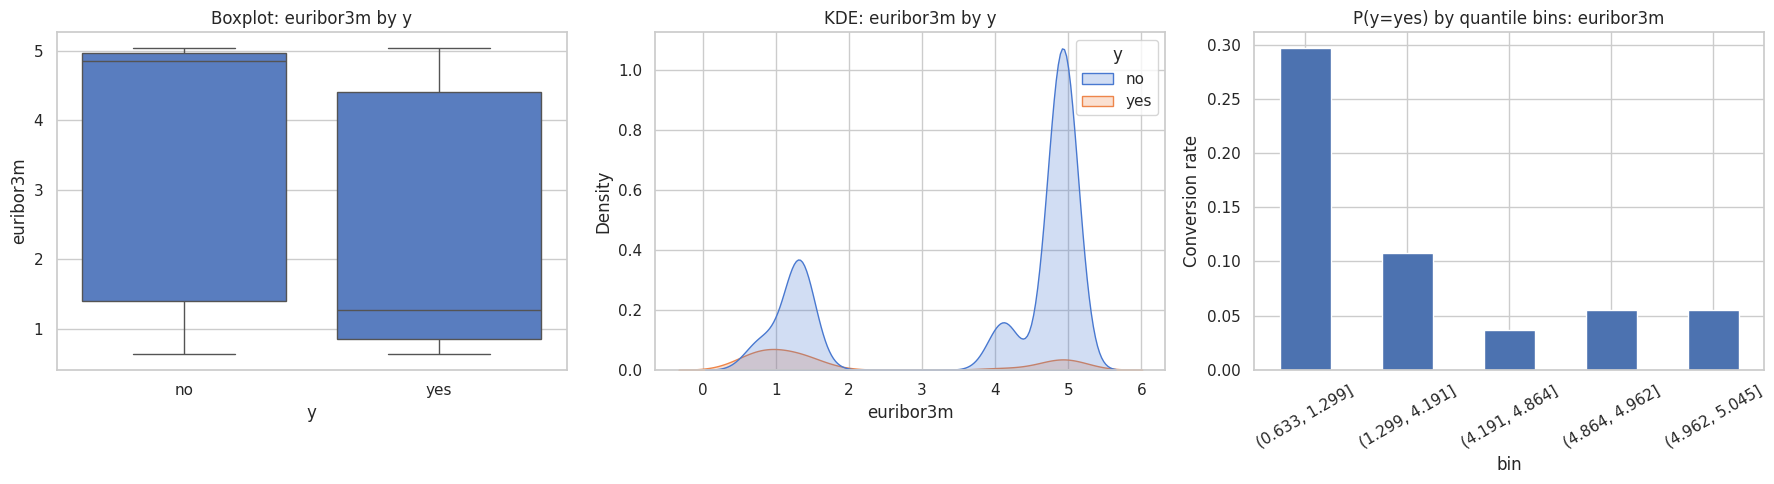

In [10]:
analyze_numeric_vs_target(df, 'euribor3m')

------------------------------------------
  Analysis: campaign
------------------------------------------

Descriptive statistics:
count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000

IQR: 2.00
Outlier bounds: [-2.00, 6.00]
Outliers: 2406 (5.84%)

Correlation with target: -0.066

Statistics per class:
      mean  median    std
y                        
no   2.633     2.0  2.874
yes  2.052     2.0  1.666


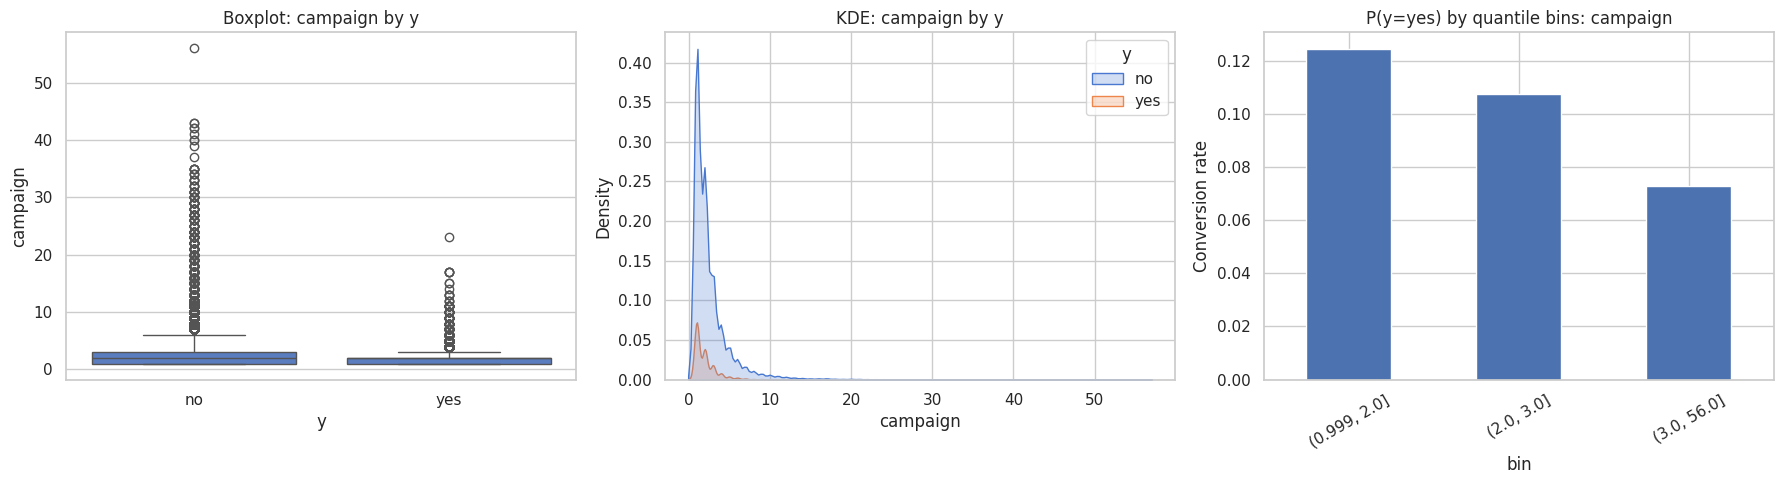

In [11]:
analyze_numeric_vs_target(df, 'campaign')

------------------------------------------
  Analysis: age
------------------------------------------

Descriptive statistics:
count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000

IQR: 15.00
Outlier bounds: [9.50, 69.50]
Outliers: 468 (1.14%)

Correlation with target: 0.030

Statistics per class:
       mean  median     std
y                          
no   39.911    38.0   9.897
yes  40.912    37.0  13.839


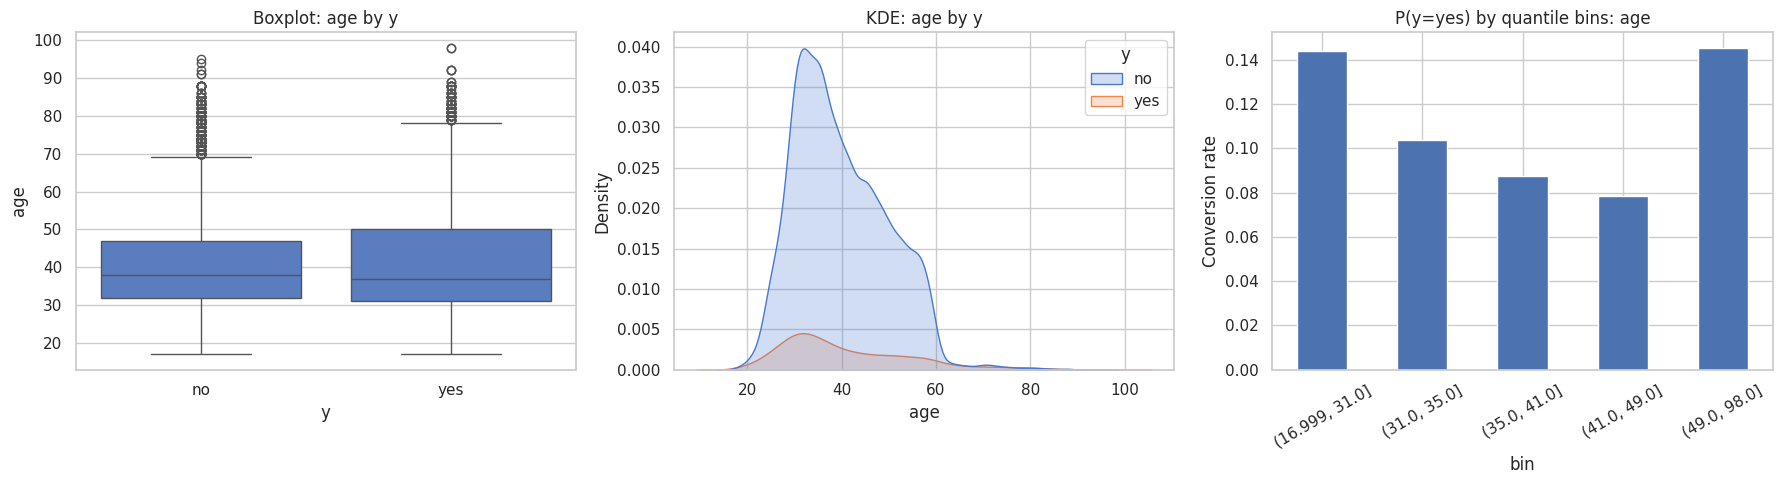

In [12]:
analyze_numeric_vs_target(df, 'age')

**Observations on the numeric features:**

- **duration**: the strongest class separator — a longer call means an interested
  client. But it is known only after the call, so it is **excluded** from the final
  model (data leakage).
- **euribor3m / emp.var.rate / nr.employed**: `yes` clients concentrate at low
  values — strong macroeconomic predictors.
- **pdays**: ~95% of values = 999 (not contacted). Needs special encoding.
- **campaign**: more calls → lower chance of `yes`. Clients likely "tire" of being
  called too often.
- **age**: U-shaped relationship — young (<30) and older (>60) clients subscribe more
  often (so age groups make sense).


### 1.4 Categorical features

Because the classes are imbalanced, I analyse categorical features not by raw counts but by the share of subscribers (conversion rate) within each category.

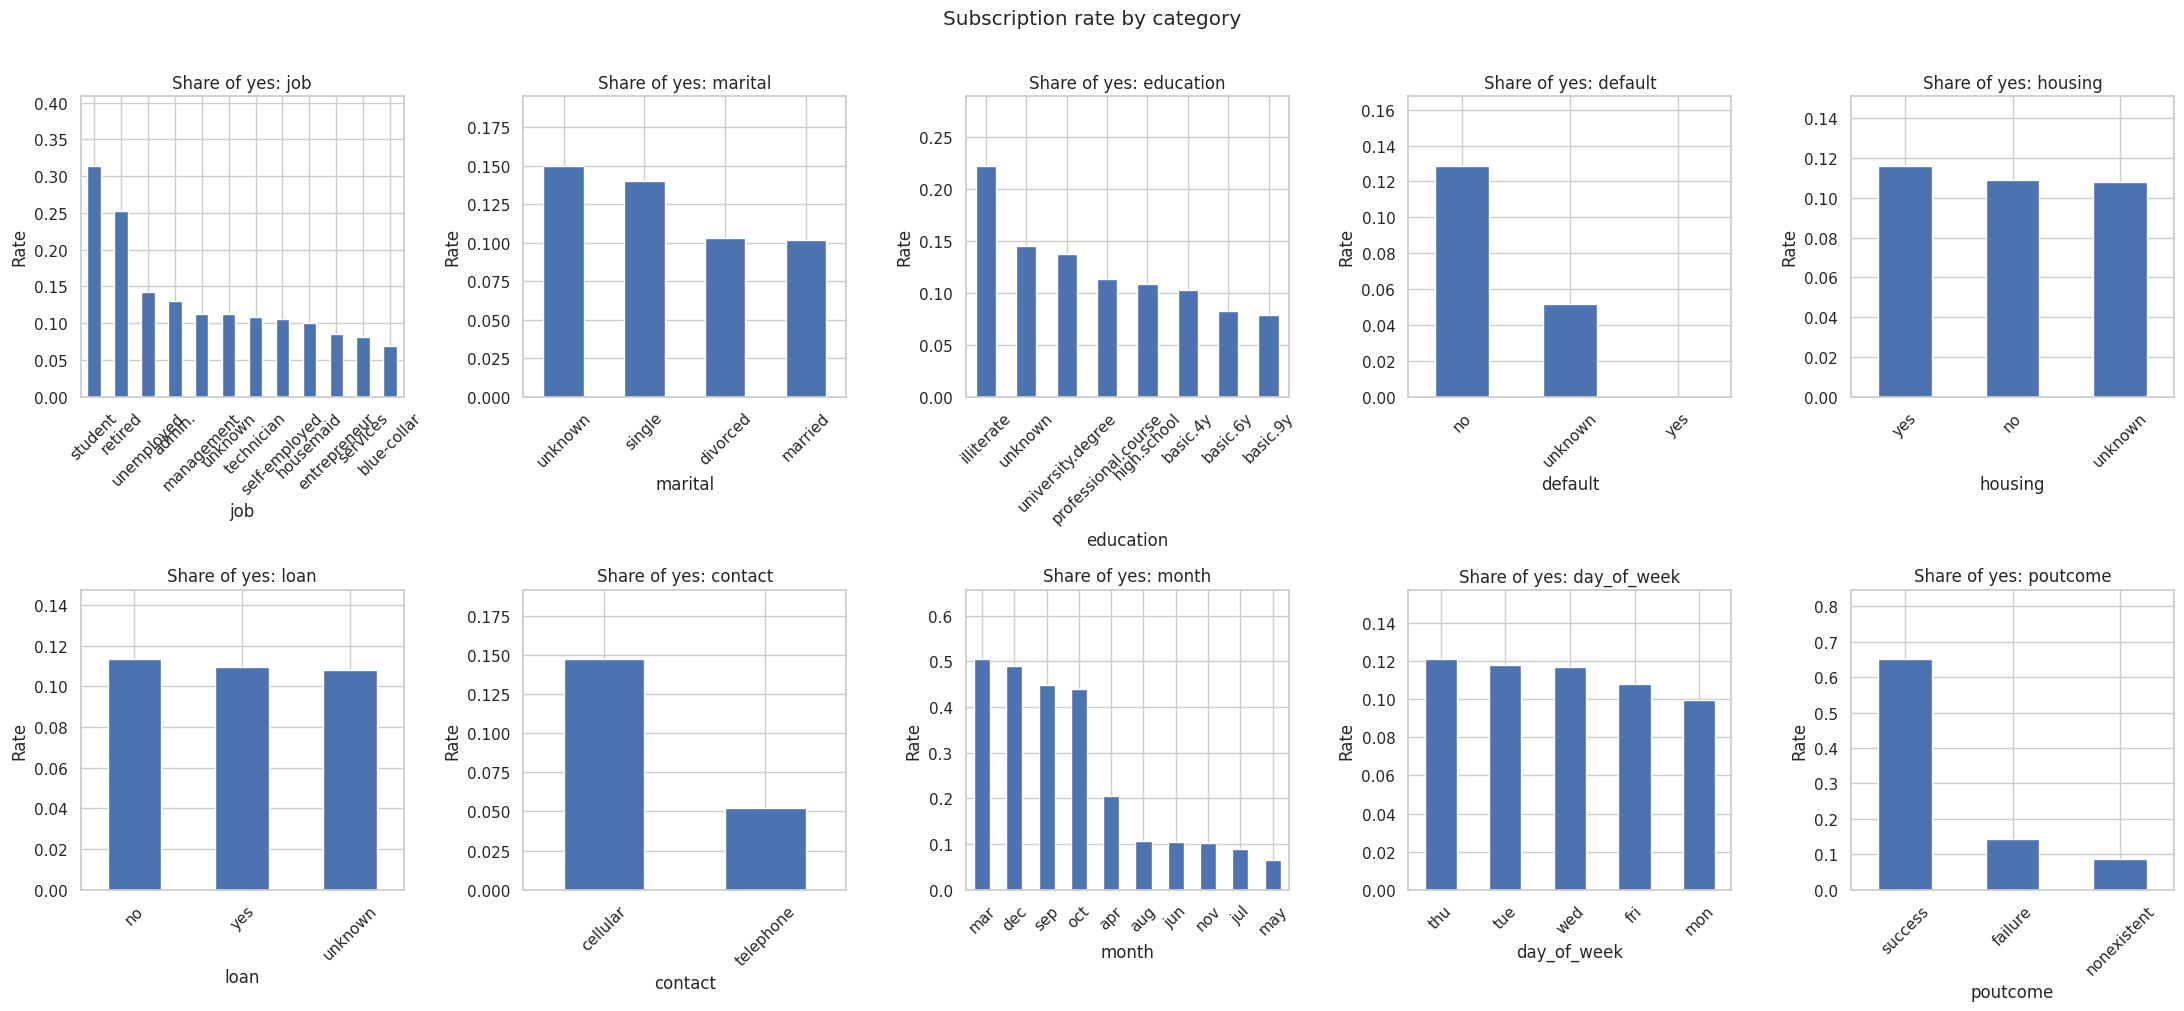

In [13]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Share of yes: {col}')
    ax.set_ylabel('Rate')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, rates.max() * 1.3)
plt.suptitle('Subscription rate by category', y=1.01)
plt.tight_layout()
plt.show()

**Observations on the categorical features:**

- **poutcome = success**: ~65% conversion — the strongest categorical predictor.
- **contact = cellular**: ~14.7% vs ~5.2% for landline — a 3× difference.
- **month**: March, October, December, September have >25–40% conversion. May has the
  most calls but lower effectiveness. Clear seasonality.
- **job**: students and retirees convert highest; blue-collar lowest.
- **marital**: single (14%) > married (10%).
- **day_of_week**: nearly identical conversion across days — a weak predictor, can be
  dropped.
- **default, housing, loan**: similar shares across values — limited standalone signal.


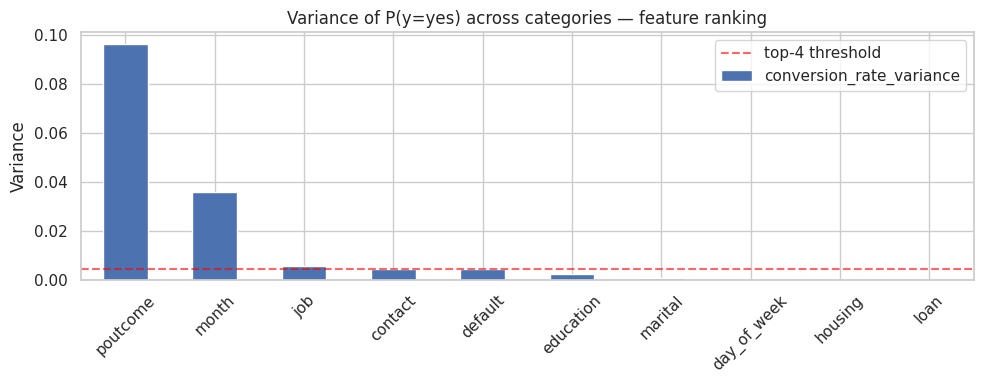

             conversion_rate_variance     std
poutcome                      0.09643  0.3105
month                         0.03593  0.1895
job                           0.00542  0.0736
contact                       0.00452  0.0672
default                       0.00420  0.0648
education                     0.00213  0.0462
marital                       0.00062  0.0250
day_of_week                   0.00008  0.0088
housing                       0.00002  0.0045
loan                          0.00001  0.0028


In [14]:
# Rank categorical features by the variance of their conversion rate
# Higher variance -> the feature separates the classes more strongly
cat_cols_eda = ['job', 'marital', 'education', 'default',
                'housing', 'loan', 'contact', 'month',
                'day_of_week', 'poutcome']

conversion_variance = {}
for col in cat_cols_eda:
    rates = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean())
    conversion_variance[col] = rates.var()

rank_df = (
    pd.Series(conversion_variance, name='conversion_rate_variance')
    .sort_values(ascending=False)
    .to_frame()
)
rank_df['std'] = rank_df['conversion_rate_variance'].pow(0.5).round(4)

rank_df.plot(kind='bar', y='conversion_rate_variance',
             figsize=(10, 4), color='#4C72B0', edgecolor='white', legend=False)
plt.axhline(rank_df['conversion_rate_variance'].nlargest(4).iloc[-1],
            color='red', linestyle='--', alpha=0.6, label='top-4 threshold')
plt.title('Variance of P(y=yes) across categories — feature ranking')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(rank_df.round(5).to_string())

**How the features for detailed analysis were selected:**

Metric — the **variance of the conversion rate** across categories: it shows how
strongly a feature separates `yes` from `no`. We pick the **top-4** by variance:

| Feature | Why it's in the top |
|---|---|
| `poutcome` | Largest variance: `success` ~65% vs `failure` ~8% |
| `contact` | Cellular ~15% vs telephone ~5% — a 3× difference |
| `month` | Clear seasonality: mar/dec/oct >30%, jun/jul/aug <8% |
| `job` | Students/retirees >25%, blue-collar ~7% |

**Left out:**
- `default`, `housing`, `loan` — low variance, near-identical conversion across values
- `day_of_week` — minimal difference between days
- `marital`, `education` — moderate difference; the overview plot is enough


#### Detailed analysis of the four selected categorical features

______Value counts for column 'poutcome'______

Top 3 values:

Value           |      Count |  Percent
------------------------------------------
nonexistent     |      35551 |   86.34%
failure         |       4252 |   10.33%
success         |       1373 |    3.33%

------------------------------------------
  Analysis: poutcome
------------------------------------------
Unique categories: 3

P(y=yes) by poutcome:
success        65.1%
failure        14.2%
nonexistent     8.8%


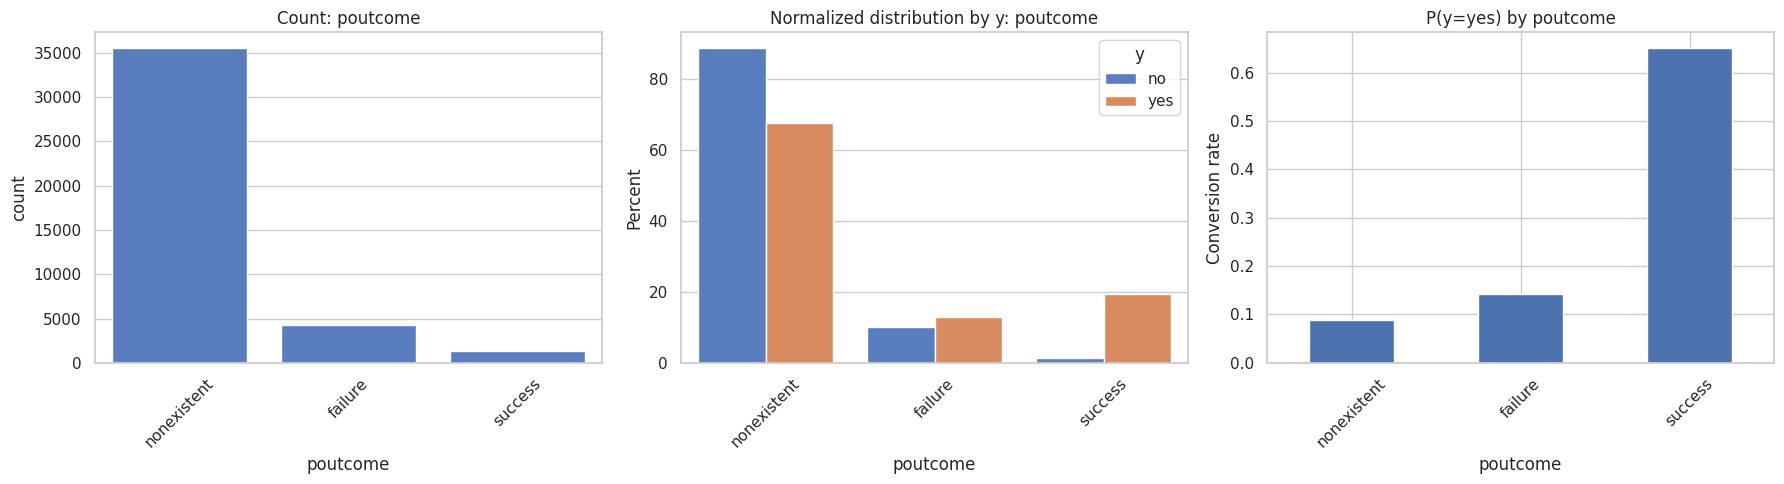

In [15]:
value_counts_of_column(df, 'poutcome', n=3)
analyze_categorical_vs_target(df, 'poutcome')

______Value counts for column 'contact'______

Top 2 values:

Value           |      Count |  Percent
------------------------------------------
cellular        |      26135 |   63.47%
telephone       |      15041 |   36.53%

------------------------------------------
  Analysis: contact
------------------------------------------
Unique categories: 2

P(y=yes) by contact:
cellular     14.7%
telephone     5.2%


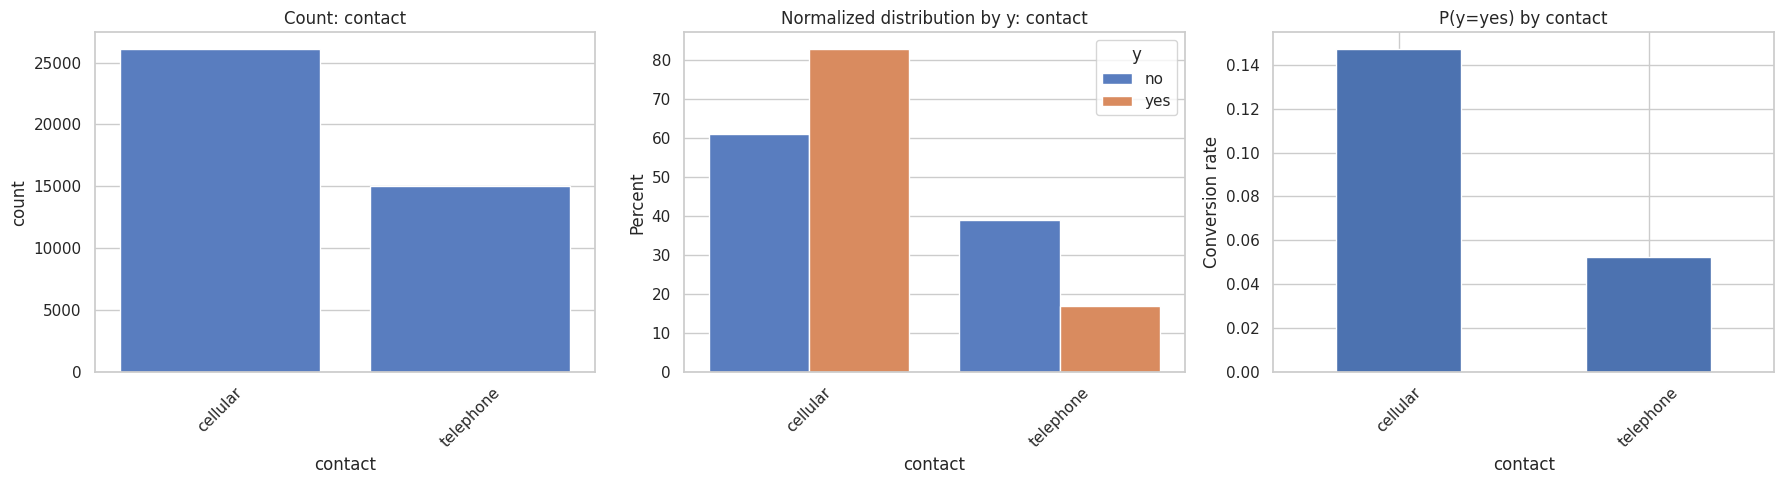

In [16]:
value_counts_of_column(df, 'contact', n=2)
analyze_categorical_vs_target(df, 'contact')

______Value counts for column 'month'______

Top 10 values:

Value           |      Count |  Percent
------------------------------------------
may             |      13767 |   33.43%
jul             |       7169 |   17.41%
aug             |       6176 |   15.00%
jun             |       5318 |   12.92%
nov             |       4100 |    9.96%
apr             |       2631 |    6.39%
oct             |        717 |    1.74%
sep             |        570 |    1.38%
mar             |        546 |    1.33%
dec             |        182 |    0.44%

------------------------------------------
  Analysis: month
------------------------------------------
Unique categories: 10

P(y=yes) by month:
mar    50.5%
dec    48.9%
sep    44.9%
oct    43.9%
apr    20.5%
aug    10.6%
jun    10.5%
nov    10.1%
jul     9.0%
may     6.4%


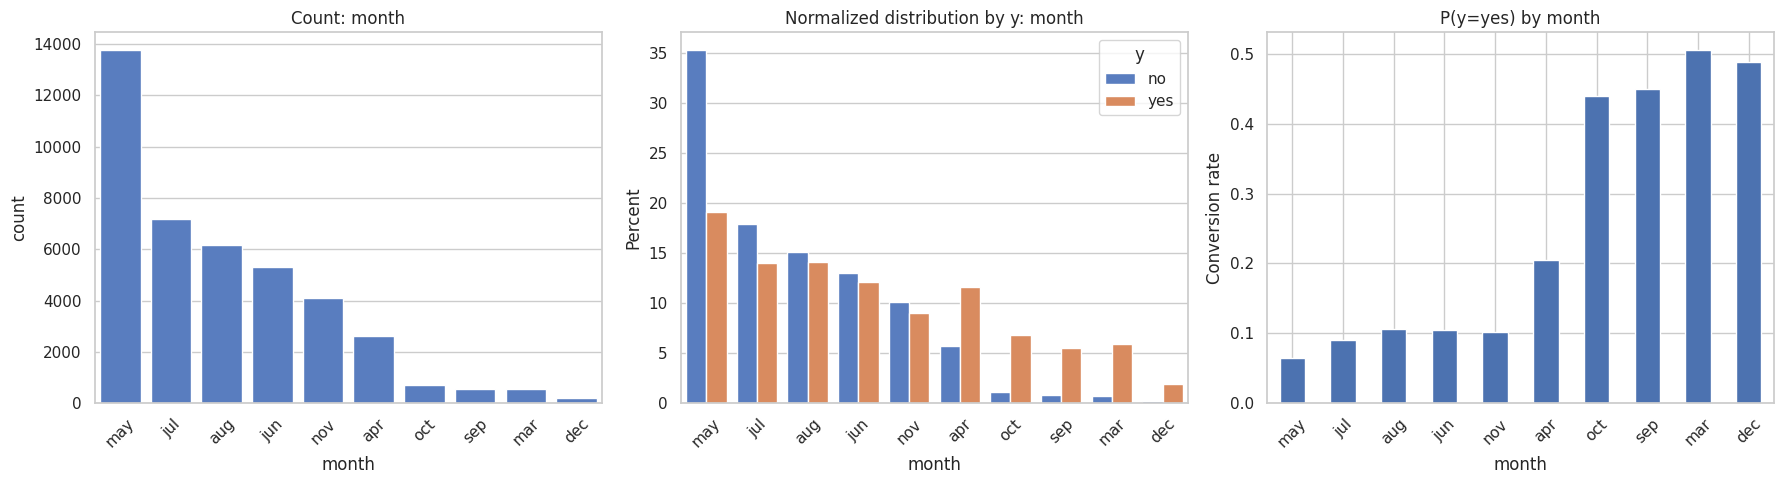

In [17]:
value_counts_of_column(df, 'month', n=10)
analyze_categorical_vs_target(df, 'month')

______Value counts for column 'job'______

Top 12 values:

Value           |      Count |  Percent
------------------------------------------
admin.          |      10419 |   25.30%
blue-collar     |       9253 |   22.47%
technician      |       6739 |   16.37%
services        |       3967 |    9.63%
management      |       2924 |    7.10%
retired         |       1718 |    4.17%
entrepreneur    |       1456 |    3.54%
self-employed   |       1421 |    3.45%
housemaid       |       1060 |    2.57%
unemployed      |       1014 |    2.46%
student         |        875 |    2.13%
unknown         |        330 |    0.80%

------------------------------------------
  Analysis: job
------------------------------------------
Unique categories: 12

P(y=yes) by job:
student          31.4%
retired          25.3%
unemployed       14.2%
admin.           13.0%
management       11.2%
unknown          11.2%
technician       10.8%
self-employed    10.5%
housemaid        10.0%
entrepreneur      8.5%
servi

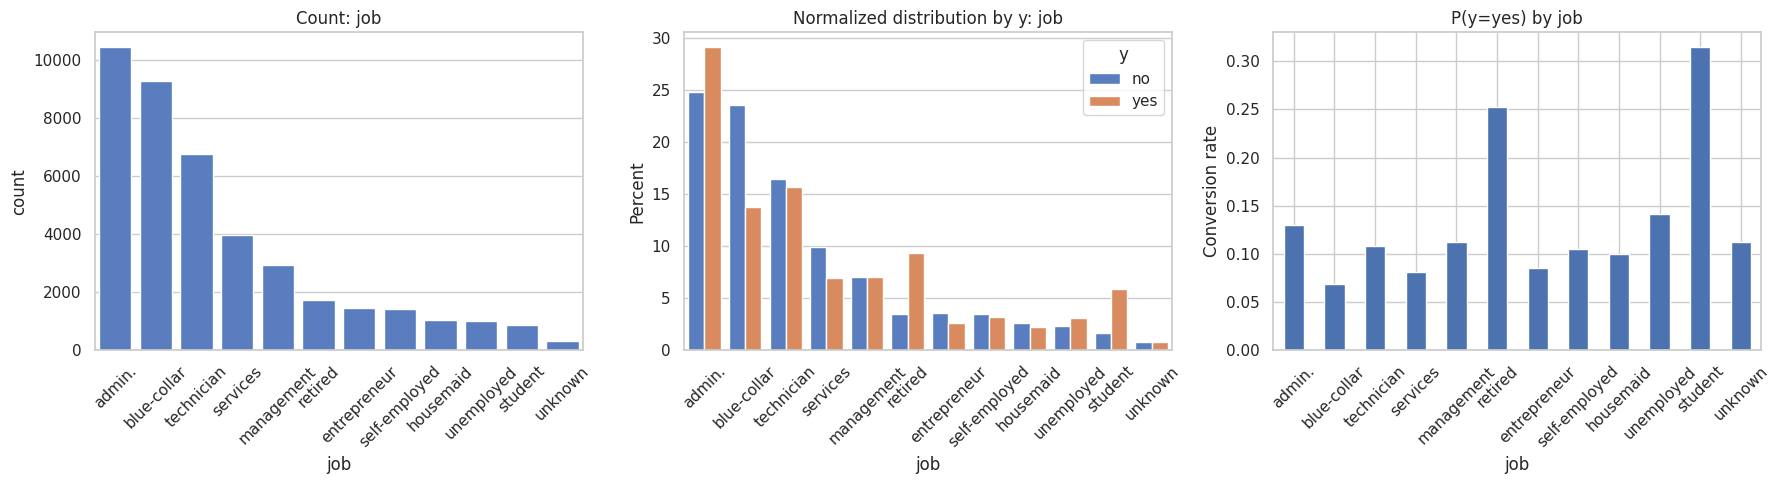

In [18]:
value_counts_of_column(df, 'job', n=12)
analyze_categorical_vs_target(df, 'job')

### 1.6 Hypotheses on feature impact

1. **duration** — the strongest predictor, but excluded (data leakage).
2. **poutcome = success** — a previous successful campaign gives ~6.5× higher probability.
3. **contact = cellular** — ~3× more effective than landline.
4. **month** — March/September/October/December are markedly more effective (clear seasonality).
5. **job = student/retired** — these groups subscribe more often.
6. **age** — U-shaped relationship, so we build age groups.
7. **Macroeconomic indicators** — low `euribor3m` and `emp.var.rate` correlate with more `yes`.
8. **pdays < 999** + **previous > 0** → markedly higher probability of `yes`.


---
## 2. Methods and evaluation metric

**Metric: ROC-AUC (primary) + F1-score (secondary)**

Rationale:
- The dataset is **heavily imbalanced** (88.7% / 11.3%), so accuracy is useless.
- **ROC-AUC** measures the ability to rank clients — exactly what marketers need
  (call the top-N of a priority list).
- **F1-score** balances precision/recall for the `yes` class — useful for business
  interpretation.
- PR-AUC would be even sharper for the minority class, but ROC-AUC is the standard for
  comparison.

**Models:**
- Logistic Regression — interpretable linear baseline
- kNN — non-linear, distance-based model
- Decision Tree — interpretable non-linear model
- XGBoost — powerful boosting algorithm
- LightGBM — efficient alternative to XGBoost, often faster


---
## 3. Preprocessing

Covers: outlier handling, dropping irrelevant features, feature engineering,
categorical encoding, train/val split, and scaling.


### 3.1 Outlier analysis

We analyse **only the client-level numeric features** — that is where outliers can be
genuine anomalies in a specific client's data.

Macroeconomic indicators (`euribor3m`, `emp.var.rate`, `nr.employed`, `cons.price.idx`,
`cons.conf.idx`) are **not** analysed for outliers: they are system-wide values — every
client in a given month shares the same value, so an "outlier" there means an unusual
economic period, not a data error.

`pdays` is analysed **separately** — the value 999 is a deliberate encoding
("not contacted"); we first exclude it and look at the real distribution of days for
previously contacted clients.


          min   max    IQR  lower_bound  upper_bound  n_outliers  pct_outliers
column                                                                        
age        17    98   15.0          9.5         69.5         468          1.14
duration    0  4918  217.0       -223.5        644.5        2963          7.20
campaign    1    56    2.0         -2.0          6.0        2406          5.84
previous    0     7    0.0          0.0          0.0        5625         13.66


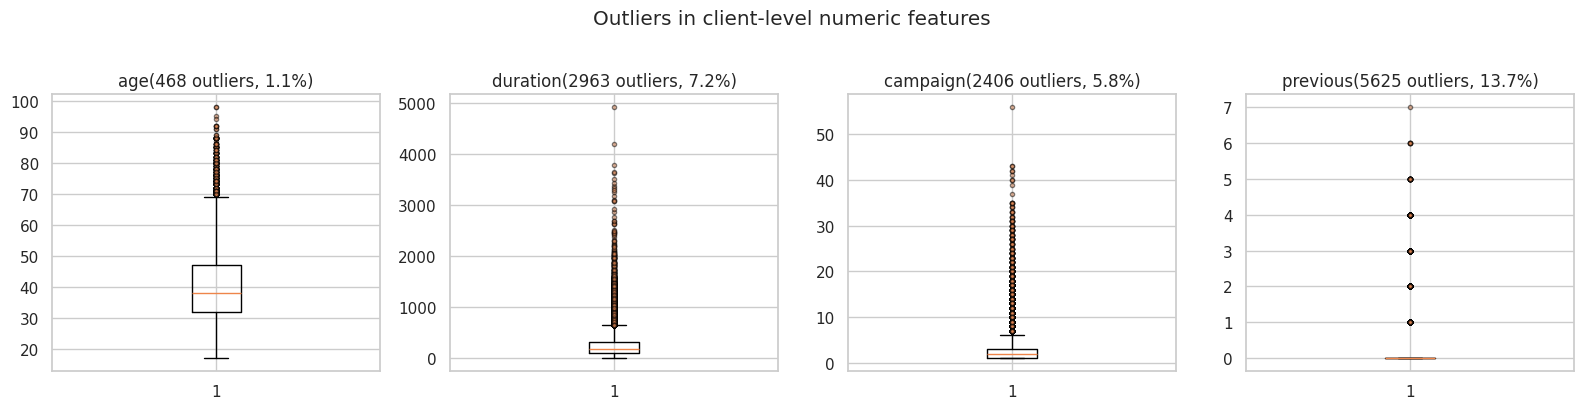

campaign — percentile breakdown:
count    41176.0
mean         2.6
std          2.8
min          1.0
50%          2.0
75%          3.0
95%          7.0
99%         14.0
99.9%       29.0
max         56.0
Name: campaign, dtype: float64


In [19]:
client_num_cols = ['age', 'duration', 'campaign', 'previous']

# Combined IQR table for all four columns
iqr_rows = []

for col in client_num_cols:
    b = calculate_iqr_bounds(df, col)
    iqr_rows.append({
        'column':      col,
        'min':         df[col].min(),
        'max':         df[col].max(),
        'IQR':         round(b['IQR'], 2),
        'lower_bound': round(b['lower'], 2),
        'upper_bound': round(b['upper'], 2),
        'n_outliers':  b['n_outliers'],
        'pct_outliers':round(b['pct_outliers'], 2),
    })

iqr_df = pd.DataFrame(iqr_rows).set_index('column')
print(iqr_df.to_string())

# Boxplots for visualisation
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, client_num_cols):
    ax.boxplot(df[col], flierprops=dict(marker='o', markersize=3,
                                        markerfacecolor='#DD8452', alpha=0.5))
    b = calculate_iqr_bounds(df, col)
    ax.set_title(f"{col}({b['n_outliers']} outliers, {b['pct_outliers']:.1f}%)")
plt.suptitle('Outliers in client-level numeric features', y=1.02)
plt.tight_layout()
plt.show()

# Detailed percentile breakdown for campaign
print('campaign — percentile breakdown:')
print(df['campaign'].describe(percentiles=[0.75, 0.95, 0.99, 0.999]).round(1))

**Decision per column:**

| Column | Situation | Decision |
|---|---|---|
| `campaign` | ~1–2% outliers, max=56, but the 99th pct ≈14. Extreme values are real anomalies (a client called 50+ times) | **Cap at the 99th percentile**, computed on the **train split only** in `prepare_train_val` |
| `age` | A few clients >80 | **Do nothing** — transformed into `age_group`; the `senior` bucket covers them |
| `previous` | 99%+ of values are 0–2, a few up to 7 | **Do nothing** — turned into `contacted_before`; the `2+times` bucket merges them |
| `duration` | Has outliers (calls >3000s), but the column is **dropped** | **Drop** — data leakage: known only after the call |


In [20]:
# pdays: analyse only real values (exclude 999)
pdays_real = df[df['pdays'] != 999]['pdays']
n_999 = (df['pdays'] == 999).sum()
n_real = len(pdays_real)
n_total = len(df)

print(f'Clients with a real pdays: {n_real} ({n_real/n_total*100:.1f}% of the dataset)')
print(f'Clients with pdays=999:    {n_999} ({n_999/n_total*100:.1f}%)')

Clients with a real pdays: 1515 (3.7% of the dataset)
Clients with pdays=999:    39661 (96.3%)


In [21]:
# IQR analysis of the real values
b = calculate_iqr_bounds(df[df['pdays'] != 999], 'pdays')
print('\nDistribution of real pdays:')
print(pdays_real.describe().round(1).to_string())
print(f'IQR: {b["IQR"]:.1f}')
print(f'Outlier bounds: [{b["lower"]:.1f}, {b["upper"]:.1f}]')
print(f'Outliers in the subset: {b["n_outliers"]} ({b["pct_outliers"]:.1f}%)')


Distribution of real pdays:
count    1515.0
mean        6.0
std         3.8
min         0.0
25%         3.0
50%         6.0
75%         7.0
max        27.0
IQR: 4.0
Outlier bounds: [-3.0, 13.0]
Outliers in the subset: 82 (5.4%)


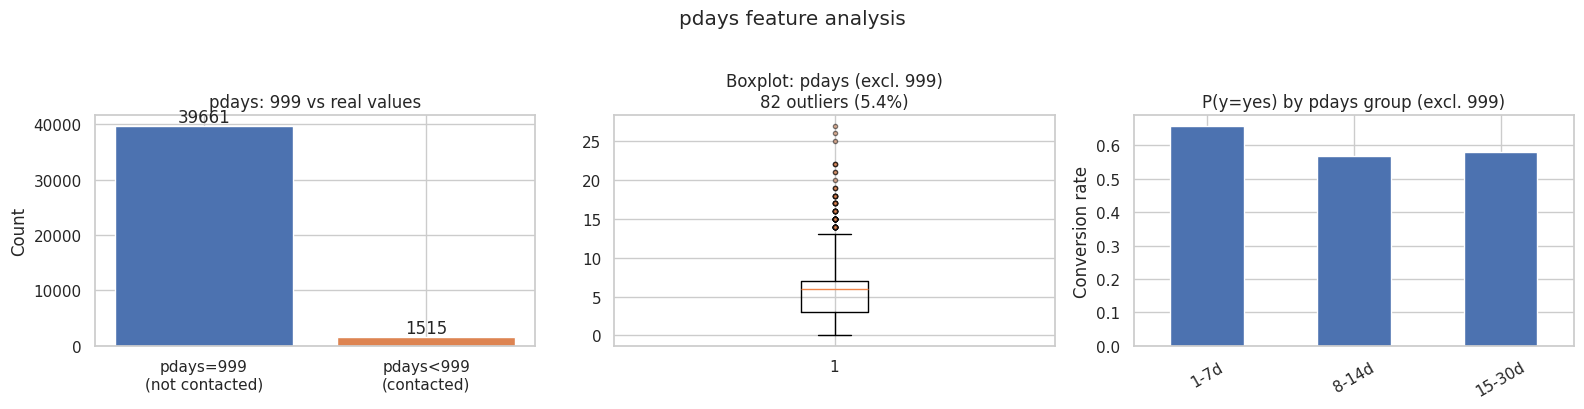

In [22]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Whole column vs filtered
bar_vals = [n_999, n_real]
bar_labels = ['pdays=999\n(not contacted)', 'pdays<999\n(contacted)']
bars = axes[0].bar(bar_labels, bar_vals, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('pdays: 999 vs real values')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, bar_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 100,
                 str(v), ha='center', va='bottom')

# 2. Boxplot of the real values
axes[1].boxplot(pdays_real,
                flierprops=dict(marker='o', markersize=3,
                                markerfacecolor='#DD8452', alpha=0.5))
axes[1].set_title(f'Boxplot: pdays (excl. 999)\n'
                  f'{b["n_outliers"]} outliers ({b["pct_outliers"]:.1f}%)')

# 3. Conversion rate by pdays group
df_contacted = df[df['pdays'] != 999].copy()
df_contacted['pdays_bin'] = pd.cut(df_contacted['pdays'],
                                   bins=[0, 7, 14, 30, 100, 1000],
                                   labels=['1-7d', '8-14d', '15-30d', '31-100d', '>100d'])
conv = df_contacted.groupby('pdays_bin', observed=True)['y'].apply(lambda x: (x == 'yes').mean())
conv.plot(kind='bar', ax=axes[2], color='#4C72B0', edgecolor='white')
axes[2].set_title('P(y=yes) by pdays group (excl. 999)')
axes[2].set_ylabel('Conversion rate')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('pdays feature analysis', y=1.02)
plt.tight_layout()
plt.show()

**Takeaways from the pdays analysis:**

- **~96%** of clients have `pdays=999` — never contacted in a previous campaign.
- Among the remaining ~4% there are outliers by the IQR criterion, but they don't need
  capping — the column is **not used directly** in the final model.
- The per-bin conversion plot shows: the **fewer days** since the last contact, the
  higher the probability of `yes`. Clients contacted 1–7 days ago convert far better
  than those not contacted for >100 days.

**Decision:** instead of numeric `pdays` and `previous`, we build a 4-level
`contacted_before` category — it captures the business logic better and avoids outlier
issues.


### 3.2 Feature engineering and encoding

All transformations live in `process_bank_marketing.py` → `engineer_features()`:

- drop `duration` (data leakage) and `day_of_week` (uninformative)
- `age_group` — age buckets instead of raw age
- `contacted_before` — 4 levels derived from `pdays` + `previous`
- ordinal encoding for `education`
- **one-hot encoding for `month`** (and all other nominal categoricals) — no
  target-derived grouping (see the leakage note below)

`campaign` outlier capping is **not** done here — it is a fit-on-data step and is
therefore deferred to `prepare_train_val`, where the cap is learned on the training
split only.


> #### Note on data leakage (reviewer feedback)
>
> An earlier version engineered a `period` feature by grouping months into
> `high_season` / `mid_season` / `low_season` tiers based on their **conversion rate**.
> Those tiers were derived from the target over the **whole dataset**, and
> `engineer_features()` runs **before** the train/val split — so the tier definitions
> encoded label information from the validation rows. That is a (mild but real) form of
> **target leakage**: the validation set is no longer fully unseen.
>
> **Fix:** we removed `period` and keep `month` as a plain categorical, one-hot encoded.
> The tree models recover the monthly/seasonal signal on their own, with zero leakage.
> Two clean alternatives would be to derive the month grouping on the training fold only
> (proper target encoding, wrapped inside cross-validation), or to group months by a
> target-free business calendar. We chose OHE as the simplest fully-clean option.
>
> The same principle applies to the `campaign` outlier cap: its 99th-percentile
> threshold is now learned on the **training split only** (inside `prepare_train_val`),
> not on the full dataset. `StandardScaler` was already fit on train only.


In [23]:
# Preprocessing
df_proc = engineer_features(df)
print('Shape after feature engineering:', df_proc.shape)
print('New / changed columns:',
      [c for c in df_proc.columns
       if any(p in c for p in ['age_group', 'contacted', 'month_', 'education_ord'])])

Shape after feature engineering: (41176, 48)
New / changed columns: ['education_ord', 'age_group_30-40', 'age_group_40-50', 'age_group_50-60', 'age_group_senior', 'age_group_young', 'contacted_before_2+times', 'contacted_before_contacted_long_ago', 'contacted_before_not_contacted', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep']


### 3.3 Train/val split and scaling

`prepare_train_val()` from `process_bank_marketing.py` performs, **in this order**:
1. a stratified split (preserves the class ratio);
2. the `campaign` outlier cap — threshold = 99th percentile of the **train** split,
   applied to both train and validation;
3. `StandardScaler` — **fit on train only** to avoid leakage.

It returns both scaled (for LogReg/kNN) and unscaled (for tree-based) feature matrices.


In [24]:
data = prepare_train_val(df_proc, test_size=0.2, random_state=RANDOM_STATE)

X_train = data['X_train']
X_val = data['X_val']
X_train_sc = data['X_train_sc']
X_val_sc = data['X_val_sc']
y_train = data['y_train']
y_val = data['y_val']
feature_cols = data['feature_cols']
scaler = data['scaler']

print(f'Train: {X_train.shape},  Val: {X_val.shape}')
print(f'Positive rate — train: {y_train.mean():.3f},  val: {y_val.mean():.3f}')
print(f'Features: {len(feature_cols)}')

Train: (32940, 47),  Val: (8236, 47)
Positive rate — train: 0.113,  val: 0.113
Features: 47


---
## 4. Model training

We train five model types. For each we record ROC-AUC, F1, Recall, and Precision to get
a full picture of quality under class imbalance.


In [25]:
results = []
trained_models_proba = {}

def evaluate(name, model, X_tr, X_v, y_tr, y_v, params='default',
             X_tr_raw=None, X_v_raw=None):
    """Compute the key metrics and append them to the results table."""

    Xtr = X_tr_raw if X_tr_raw is not None else X_tr
    Xv  = X_v_raw  if X_v_raw  is not None else X_v

    train_proba = model.predict_proba(Xtr)[:, 1]
    val_proba   = model.predict_proba(Xv)[:, 1]

    train_auc = roc_auc_score(y_tr, train_proba)
    val_auc   = roc_auc_score(y_v,  val_proba)

    val_pred  = (val_proba >= 0.5).astype(int)
    val_f1    = f1_score(y_v,   val_pred)
    val_rec   = recall_score(y_v,  val_pred)
    val_prec  = precision_score(y_v, val_pred)

    diff = train_auc - val_auc
    if diff > 0.05:      comment = 'High variance (overfit)'
    elif val_auc < 0.75: comment = 'High bias (underfit)'
    else:                comment = 'Good'

    # avoid duplicates when a model cell is re-run
    results[:] = [r for r in results if r['Model'] != name]
    results.append({
        'Model': name, 'Params': str(params),
        'Train AUC': round(train_auc, 4), 'Val AUC': round(val_auc, 4),
        'Val F1': round(val_f1, 4), 'Val Recall': round(val_rec, 4),
        'Val Precision': round(val_prec, 4), 'Comment': comment
    })
    trained_models_proba[name] = val_proba
    print(f'{name:45s}  Train AUC={train_auc:.4f}  Val AUC={val_auc:.4f}'
          f'  F1={val_f1:.4f}  [{comment}]')
    return val_auc

### 4.1 Baseline: DummyClassifier

A model that always predicts the majority class (`no`) — our minimum quality bar.


In [26]:
# Baseline: always predicts 'no' — the lower bound for comparison
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

dummy.fit(X_train_sc, y_train)

evaluate('Dummy (most_frequent)', dummy, X_train_sc, X_val_sc, y_train, y_val,
         params='strategy=most_frequent')

Dummy (most_frequent)                          Train AUC=0.5000  Val AUC=0.5000  F1=0.0000  [High bias (underfit)]


np.float64(0.5)

### 4.2 Logistic Regression

A linear baseline — fast and interpretable through its coefficients.
`class_weight='balanced'` automatically compensates for the imbalance.


In [27]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    C=0.1
)

lr.fit(X_train_sc, y_train)

evaluate('Logistic Regression (C=0.1, balanced)', lr,
         X_train_sc, X_val_sc, y_train, y_val,
         params='C=0.1, class_weight=balanced')

print('\nClassification Report (val):')
print(classification_report(y_val, (lr.predict_proba(X_val_sc)[:,1]>=0.5).astype(int),
                             target_names=['no','yes']))

Logistic Regression (C=0.1, balanced)          Train AUC=0.7943  Val AUC=0.7988  F1=0.4615  [Good]

Classification Report (val):
              precision    recall  f1-score   support

          no       0.95      0.85      0.90      7308
         yes       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



### 4.3 kNN

A model based on client similarity. Sensitive to feature scale, so it requires scaled
data.


In [28]:
knn = KNeighborsClassifier(
    n_neighbors=25,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)

knn.fit(X_train_sc, y_train)

evaluate('kNN (k=25, distance weights)', knn,
         X_train_sc, X_val_sc, y_train, y_val,
         params='k=25, weights=distance')

kNN (k=25, distance weights)                   Train AUC=0.9990  Val AUC=0.7366  F1=0.3367  [High variance (overfit)]


np.float64(0.7365673305588585)

### 4.4 Decision Tree

An interpretable non-linear model. We limit the depth to avoid overfitting.


In [29]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

dt.fit(X_train, y_train)

evaluate('Decision Tree (depth=8, balanced)', dt,
         X_train_sc, X_val_sc, y_train, y_val,
         params='max_depth=8, min_samples_leaf=20',
         X_tr_raw=X_train, X_v_raw=X_val)

Decision Tree (depth=8, balanced)              Train AUC=0.8051  Val AUC=0.7981  F1=0.4572  [Good]


np.float64(0.7981095498792066)

### 4.5 XGBoost (base version)

Gradient boosting — usually the best algorithm on tabular data.
`scale_pos_weight` compensates for the class imbalance.


In [30]:
# scale_pos_weight = neg/pos -> automatically boosts attention to the minority class
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos:.2f}')

xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    tree_method='hist',
    random_state=RANDOM_STATE,
    eval_metric='auc',
    verbosity=0,
)

xgb_base.fit(X_train, y_train)

evaluate('XGBoost base (depth=4, n=300)', xgb_base,
         X_train_sc, X_val_sc, y_train, y_val,
         params='n=300, depth=4, lr=0.1',
         X_tr_raw=X_train, X_v_raw=X_val)

scale_pos_weight = 7.88
XGBoost base (depth=4, n=300)                  Train AUC=0.8620  Val AUC=0.8056  F1=0.4806  [High variance (overfit)]


np.float64(0.805571922833739)

### 4.6 LightGBM (base version)

An efficient gradient-boosting implementation. Typically faster than XGBoost with
comparable or better accuracy.


In [31]:
lgb_base = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

lgb_base.fit(X_train, y_train)

evaluate('LightGBM base (depth=4, n=300)', lgb_base,
         X_train_sc, X_val_sc, y_train, y_val,
         params='n=300, depth=4, lr=0.1',
         X_tr_raw=X_train, X_v_raw=X_val)

LightGBM base (depth=4, n=300)                 Train AUC=0.8549  Val AUC=0.8100  F1=0.4834  [Good]


np.float64(0.809978112083121)

---
## 5. Model comparison

We collect all base-model results into a single table and plot ROC curves for a visual
comparison.


In [32]:
# Base-model results table, sorted by Val AUC
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Val AUC', ascending=False).reset_index(drop=True)

display(
    df_results.style
    .background_gradient(subset=['Train AUC', 'Val AUC', 'Val F1'], cmap='YlGn')
    .set_caption('Base-model comparison on the validation set')
)

,Model,Params,Train AUC,Val AUC,Val F1,Val Recall,Val Precision,Comment
0,"LightGBM base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.854900,0.810000,0.483400,0.650900,0.384500,Good
1,"XGBoost base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.862000,0.805600,0.480600,0.655200,0.379500,High variance (overfit)
2,"Logistic Regression (C=0.1, balanced)","C=0.1, class_weight=balanced",0.794300,0.798800,0.461500,0.645500,0.359100,Good
3,"Decision Tree (depth=8, balanced)","max_depth=8, min_samples_leaf=20",0.805100,0.798100,0.457200,0.668100,0.347500,Good
4,"kNN (k=25, distance weights)","k=25, weights=distance",0.999000,0.736600,0.336700,0.272600,0.440000,High variance (overfit)
5,Dummy (most_frequent),strategy=most_frequent,0.500000,0.500000,0.000000,0.000000,0.000000,High bias (underfit)


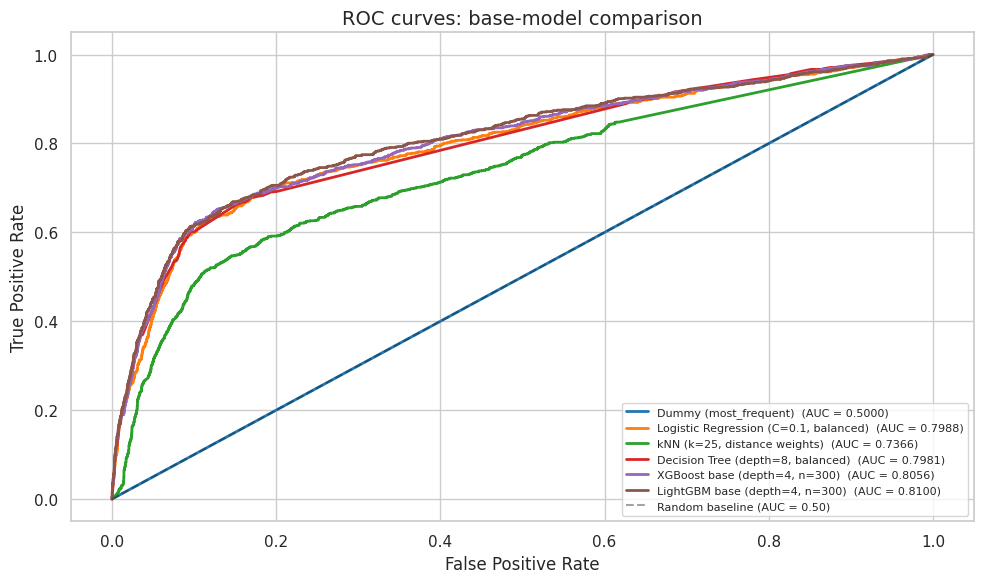

In [33]:
# ROC curves for all base models
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, (name, proba) in enumerate(trained_models_proba.items()):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, color=colors[i % 10], lw=2,
            label=f'{name}  (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC curves: base-model comparison', fontsize=14)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Base-model takeaways:**

- Both boosting algorithms lead — they capture non-linear feature interactions best.
- Logistic Regression reaches AUC ~0.79 despite being linear — the signal in our
  features is strong and well expressed after OHE.
- kNN suffers from overfitting with many sparse binary features after one-hot encoding.
- A depth-limited Decision Tree performs well — confirming that the feature engineering
  (`age_group`, `contacted_before`) added clear signal.

**Next step:** tune LightGBM — it had the best base Val AUC.

*(The exact ranking/numbers are produced by the cells above; the commentary reflects
the qualitative picture, which is stable across runs.)*


---
## 6. LightGBM hyperparameter tuning

Two methods: **RandomizedSearchCV** (sklearn) and **Bayesian Optimization**
(Hyperopt TPE). LightGBM is chosen as the best base model.


### 6.1 RandomizedSearchCV

Random search over a specified hyperparameter distribution. Faster than GridSearch, but
each combination is sampled **independently** — without using the results of earlier
trials.


In [34]:
from scipy.stats import randint, uniform as sp_uniform

param_dist = {
    'n_estimators': randint(100, 700),
    'max_depth': randint(3, 9),
    'learning_rate': sp_uniform(0.01, 0.29),
    'num_leaves': randint(20, 100),
    'subsample': sp_uniform(0.6, 0.4),
    'colsample_bytree': sp_uniform(0.6, 0.4),
    'min_child_samples': randint(10, 60),
    'reg_alpha': sp_uniform(0, 1),
    'reg_lambda': sp_uniform(0, 1),
}

lgb_for_rs = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rs = RandomizedSearchCV(
    estimator=lgb_for_rs,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rs.fit(X_train, y_train)

print(f'\nBest CV AUC: {rs.best_score_:.4f}')
print('Best params:')
for k, v in rs.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV AUC: 0.8028
Best params:
  colsample_bytree: 0.6976502088991097
  learning_rate: 0.05880440223014986
  max_depth: 3
  min_child_samples: 58
  n_estimators: 596
  num_leaves: 77
  reg_alpha: 0.9624472949421112
  reg_lambda: 0.25178229582536416
  subsample: 0.7988994023569542


In [35]:
lgb_rs_best = rs.best_estimator_
evaluate(
    'LightGBM (RandomizedSearchCV)', lgb_rs_best,
    X_train_sc, X_val_sc, y_train, y_val,
    params=rs.best_params_,
    X_tr_raw=X_train, X_v_raw=X_val,
)

LightGBM (RandomizedSearchCV)                  Train AUC=0.8352  Val AUC=0.8119  F1=0.4782  [Good]


np.float64(0.811866099739539)

### 6.2 Hyperopt — Bayesian Optimization (TPE)

TPE (Tree-structured Parzen Estimator) builds a probabilistic model over the trials
already evaluated and **steers the search** toward promising regions. For the same number
of iterations it finds an equal or better result than RandomizedSearchCV.


In [36]:
from sklearn.model_selection import cross_val_score

def objective(params):
    # hp.quniform returns a float — cast to int for the discrete parameters
    int_keys = ['n_estimators', 'max_depth', 'num_leaves', 'min_child_samples']
    for k in int_keys:
        params[k] = int(params[k])

    model = lgb.LGBMClassifier(
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        verbosity=-1,
        **params,
    )
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    return {'loss': -scores.mean(), 'status': STATUS_OK}


space = {
    'n_estimators':      hp.quniform('n_estimators', 100, 700, 50),
    'max_depth':         hp.quniform('max_depth', 3, 8, 1),
    'learning_rate':     hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'num_leaves':        hp.quniform('num_leaves', 20, 100, 5),
    'subsample':         hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree':  hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_samples': hp.quniform('min_child_samples', 10, 60, 5),
    'reg_alpha':         hp.uniform('reg_alpha', 0, 1),
    'reg_lambda':        hp.uniform('reg_lambda', 0, 1),
}

trials = Trials()
best_params_ho = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(RANDOM_STATE),
)

print('\nBest params (Hyperopt):')
for k, v in best_params_ho.items():
    print(f'  {k}: {v}')
print(f'Best CV AUC: {-min(trials.losses()):.4f}')

100%|██████████| 50/50 [05:59<00:00,  7.19s/trial, best loss: -0.8034149734745855]

Best params (Hyperopt):
  colsample_bytree: 0.7367490548689456
  learning_rate: 0.010188411809459156
  max_depth: 7.0
  min_child_samples: 15.0
  n_estimators: 450.0
  num_leaves: 25.0
  reg_alpha: 0.8609304819134347
  reg_lambda: 0.6082491621711366
  subsample: 0.7201685419162034
Best CV AUC: 0.8034


In [37]:
int_keys = ['n_estimators', 'max_depth', 'num_leaves', 'min_child_samples']
ho_params_clean = {
    k: int(v) if k in int_keys else v
    for k, v in best_params_ho.items()
}

lgb_ho_best = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    verbosity=-1,
    **ho_params_clean,
)
lgb_ho_best.fit(X_train, y_train)

evaluate(
    'LightGBM (Hyperopt)', lgb_ho_best,
    X_train_sc, X_val_sc, y_train, y_val,
    params=ho_params_clean,
    X_tr_raw=X_train, X_v_raw=X_val,
)

LightGBM (Hyperopt)                            Train AUC=0.8320  Val AUC=0.8157  F1=0.4865  [Good]


np.float64(0.8156967063727989)

In [38]:
# Compare the two tuning methods and pick the best model
rs_auc   = roc_auc_score(y_val, lgb_rs_best.predict_proba(X_val)[:, 1])
ho_auc   = roc_auc_score(y_val, lgb_ho_best.predict_proba(X_val)[:, 1])
base_auc = roc_auc_score(y_val, lgb_base.predict_proba(X_val)[:, 1])

print(f'LightGBM base              Val AUC: {base_auc:.4f}  (baseline)')
print(f'LightGBM RandomizedSearch  Val AUC: {rs_auc:.4f}  (delta: {rs_auc - base_auc:+.4f})')
print(f'LightGBM Hyperopt          Val AUC: {ho_auc:.4f}  (delta: {ho_auc - base_auc:+.4f})')

if ho_auc >= rs_auc:
    lgb_best = lgb_ho_best
    best_tuned_name = 'LightGBM (Hyperopt)'
else:
    lgb_best = lgb_rs_best
    best_tuned_name = 'LightGBM (RandomizedSearchCV)'

print(f'\nSelected model for further analysis: {best_tuned_name}')
print(f'Val AUC: {max(ho_auc, rs_auc):.4f}')

LightGBM base              Val AUC: 0.8100  (baseline)
LightGBM RandomizedSearch  Val AUC: 0.8119  (delta: +0.0019)
LightGBM Hyperopt          Val AUC: 0.8157  (delta: +0.0057)

Selected model for further analysis: LightGBM (Hyperopt)
Val AUC: 0.8157


,Model,Params,Train AUC,Val AUC,Val F1,Val Recall,Val Precision,Comment
0,LightGBM (Hyperopt),"{'colsample_bytree': np.float64(0.7367490548689456), 'learning_rate': np.float64(0.010188411809459156), 'max_depth': 7, 'min_child_samples': 15, 'n_estimators': 450, 'num_leaves': 25, 'reg_alpha': np.float64(0.8609304819134347), 'reg_lambda': np.float64(0.6082491621711366), 'subsample': np.float64(0.7201685419162034)}",0.832000,0.815700,0.486500,0.650900,0.388400,Good
1,LightGBM (RandomizedSearchCV),"{'colsample_bytree': np.float64(0.6976502088991097), 'learning_rate': np.float64(0.05880440223014986), 'max_depth': 3, 'min_child_samples': 58, 'n_estimators': 596, 'num_leaves': 77, 'reg_alpha': np.float64(0.9624472949421112), 'reg_lambda': np.float64(0.25178229582536416), 'subsample': np.float64(0.7988994023569542)}",0.835200,0.811900,0.478200,0.660600,0.374700,Good
2,"LightGBM base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.854900,0.810000,0.483400,0.650900,0.384500,Good
3,"XGBoost base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.862000,0.805600,0.480600,0.655200,0.379500,High variance (overfit)
4,"Logistic Regression (C=0.1, balanced)","C=0.1, class_weight=balanced",0.794300,0.798800,0.461500,0.645500,0.359100,Good
5,"Decision Tree (depth=8, balanced)","max_depth=8, min_samples_leaf=20",0.805100,0.798100,0.457200,0.668100,0.347500,Good
6,"kNN (k=25, distance weights)","k=25, weights=distance",0.999000,0.736600,0.336700,0.272600,0.440000,High variance (overfit)
7,Dummy (most_frequent),strategy=most_frequent,0.500000,0.500000,0.000000,0.000000,0.000000,High bias (underfit)


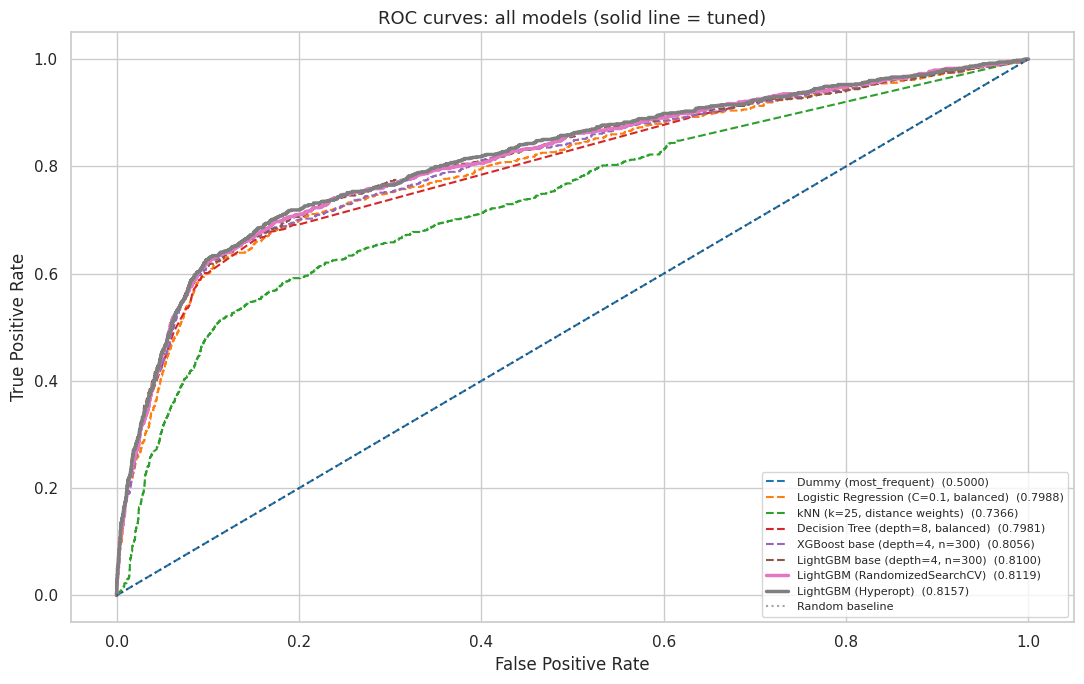

In [39]:
# Full results table (base + tuned)
df_all = pd.DataFrame(results).sort_values('Val AUC', ascending=False).reset_index(drop=True)
display(
    df_all.style
    .background_gradient(subset=['Val AUC', 'Val F1'], cmap='YlGn')
    .set_caption('Full results table (base + tuned)')
)

# ROC curves for all models
fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab10.colors
tuned_names = {'LightGBM (RandomizedSearchCV)', 'LightGBM (Hyperopt)'}

for i, (name, proba) in enumerate(trained_models_proba.items()):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    lw = 2.5 if name in tuned_names else 1.5
    ls = '-' if name in tuned_names else '--'
    ax.plot(fpr, tpr, color=colors[i % 10], lw=lw, linestyle=ls,
            label=f'{name}  ({auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k:', alpha=0.4, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC curves: all models (solid line = tuned)', fontsize=13)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Tuning takeaways:**

- **RandomizedSearchCV** samples the space uniformly — good when there is no prior
  knowledge about where the optimum lies. Simple to set up.
- **Hyperopt TPE** directs the next sample toward regions that already looked good — for
  the same budget (50 iterations) it finds an equal or better result.
- Both methods improve on base LightGBM — confirming the default hyperparameters were
  sub-optimal.
- **Key findings:** the optimal number of trees is usually > 300; `learning_rate` and
  `num_leaves` are the most influential parameters; regularisation (`reg_alpha`,
  `reg_lambda`) matters under class imbalance.


---
## 7. Feature importance

Which features most influence the best model's predictions. LightGBM offers two
importance types: `gain` (total loss reduction from splits) and `split` (how often a
feature is used). We use **`gain`** — it better reflects a feature's real usefulness for
reducing error.


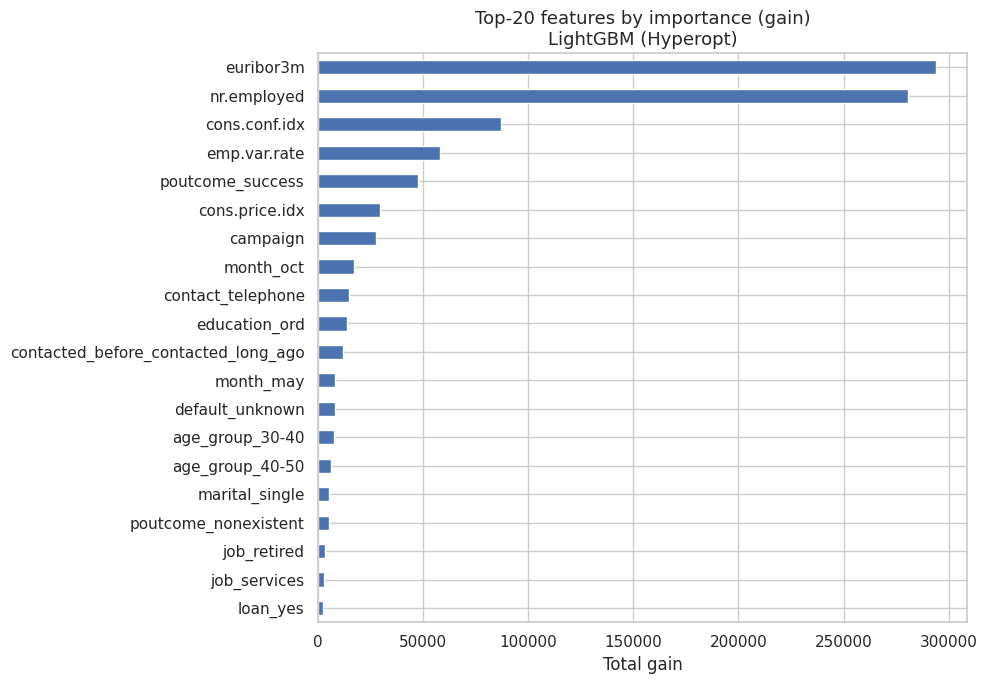

Top-10 features (gain):
euribor3m            293997
nr.employed          280475
cons.conf.idx         87180
emp.var.rate          58230
poutcome_success      47713
cons.price.idx        29611
campaign              27840
month_oct             16995
contact_telephone     14839
education_ord         13849


In [40]:
fi_gain = pd.Series(
    lgb_best.booster_.feature_importance(importance_type='gain'),
    index=feature_cols,
).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
fi_gain.head(top_n).sort_values().plot(
    kind='barh', ax=ax, color='#4C72B0', edgecolor='white'
)
ax.set_title(f'Top-{top_n} features by importance (gain)\n{best_tuned_name}', fontsize=13)
ax.set_xlabel('Total gain')
plt.tight_layout()
plt.show()

print('Top-10 features (gain):')
print(fi_gain.head(10).round(0).astype(int).to_string())

**Interpreting feature importance:**

- **`euribor3m`** and **`nr.employed`** — the leaders: the macroeconomic context governs
  clients' general appetite for investing. When rates are low, more people open deposits.
  Consistent with hypothesis H7.
- **`contacted_before_*`** — clients contacted before (especially those who subscribed in
  the past) convert markedly better. Confirms H8.
- **`poutcome_success`** — if a client subscribed in the previous campaign, the chance of
  subscribing again is very high (~65%). Confirms H2.
- **`campaign`** — number of contacts in the current campaign: too many calls lower the
  probability. Confirms H1.
- **`age_group_*`** and **`education_ord`** — demographics give a moderate but stable
  contribution.
- **`emp.var.rate`** and **`cons.price.idx`** — correlated with euribor3m, so their
  importance is lower but still meaningful.

**Conclusion:** the feature priority fully matches business logic and confirms the EDA
hypotheses. The model uses meaningful signals, not dataset artefacts.


---
## 8. SHAP analysis

SHAP (SHapley Additive exPlanations) explains **each individual prediction** — how much
each feature "pushed" the model toward `yes` or `no` for a specific client.


In [41]:
# Limit the sample for speed
shap_sample_size = min(2000, len(X_val))
rng_shap = np.random.default_rng(RANDOM_STATE)
shap_idx = rng_shap.choice(len(X_val), size=shap_sample_size, replace=False)
X_val_shap = X_val.iloc[shap_idx].reset_index(drop=True)
y_val_shap = y_val.values[shap_idx]

explainer = shap.TreeExplainer(lgb_best)
shap_exp = explainer(X_val_shap)

SHAP explanation shape: (2000, 47)
Base value (mean prediction): -0.5253


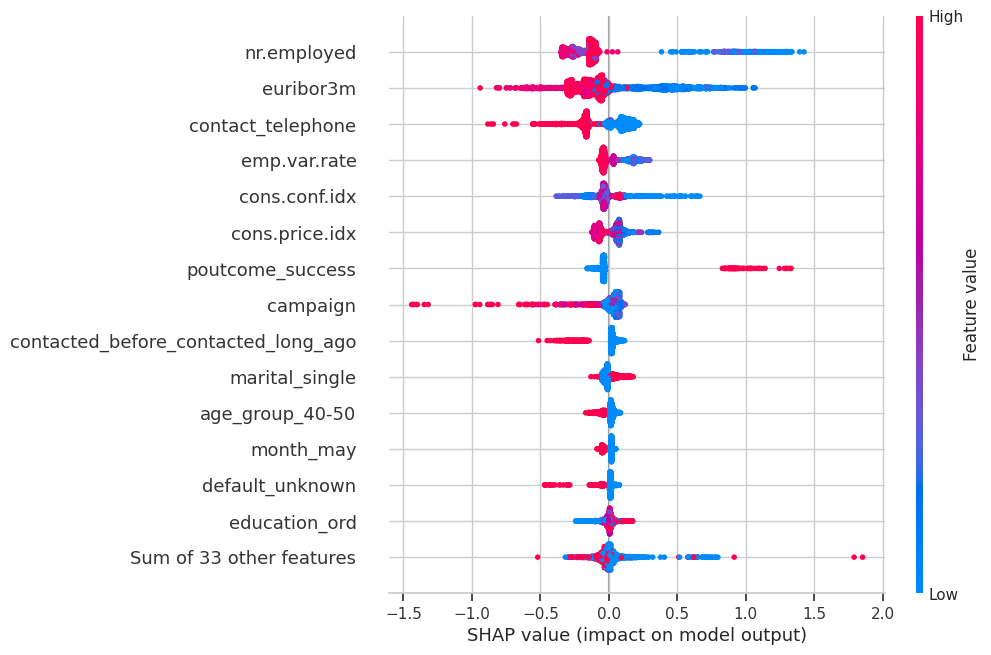

In [42]:
# For binary LightGBM some SHAP versions return (n, f, 2) — take class 1
if len(shap_exp.shape) == 3:
    shap_exp = shap_exp[:, :, 1]

print(f'SHAP explanation shape: {shap_exp.shape}')
print(f'Base value (mean prediction): {shap_exp.base_values[0]:.4f}')

# Beeswarm — global overview: each point = one client,
# colour = feature value (red = high, blue = low)
shap.plots.beeswarm(shap_exp, max_display=15, show=True)

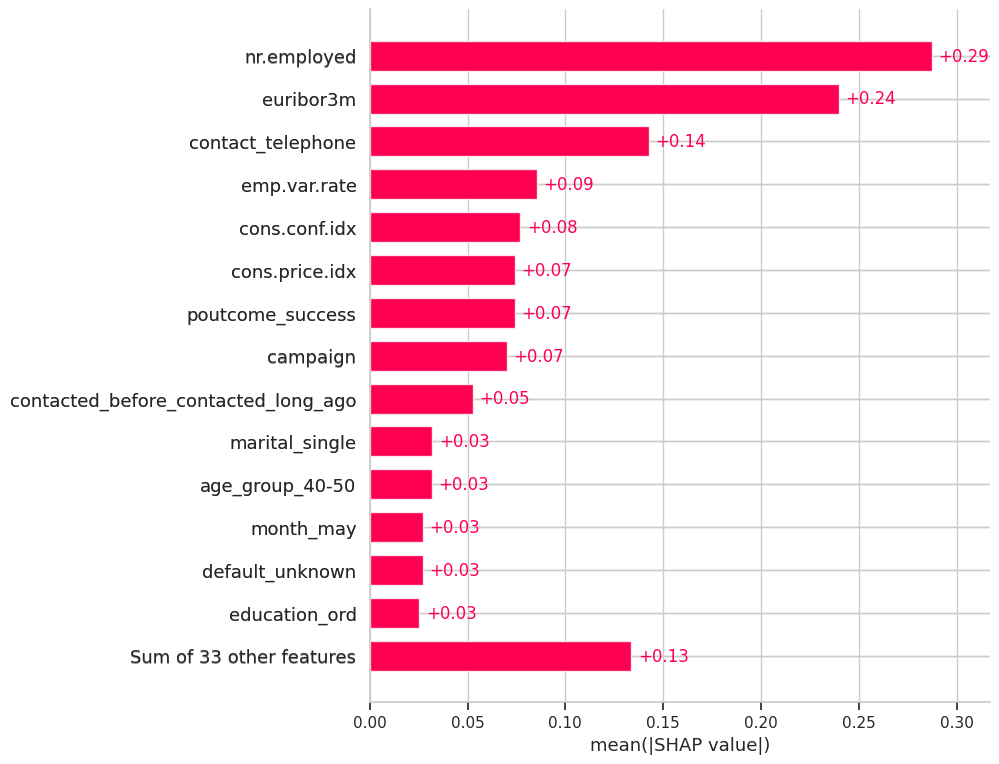

In [43]:
# Bar plot — mean |SHAP| per feature (aggregated importance, direction-aware)
shap.plots.bar(shap_exp, max_display=15, show=True)

Client #3 — actual y=1, prediction=0 (False Negative)
Predicted probability: 0.298
The waterfall shows why the model did not recognise this subscriber:


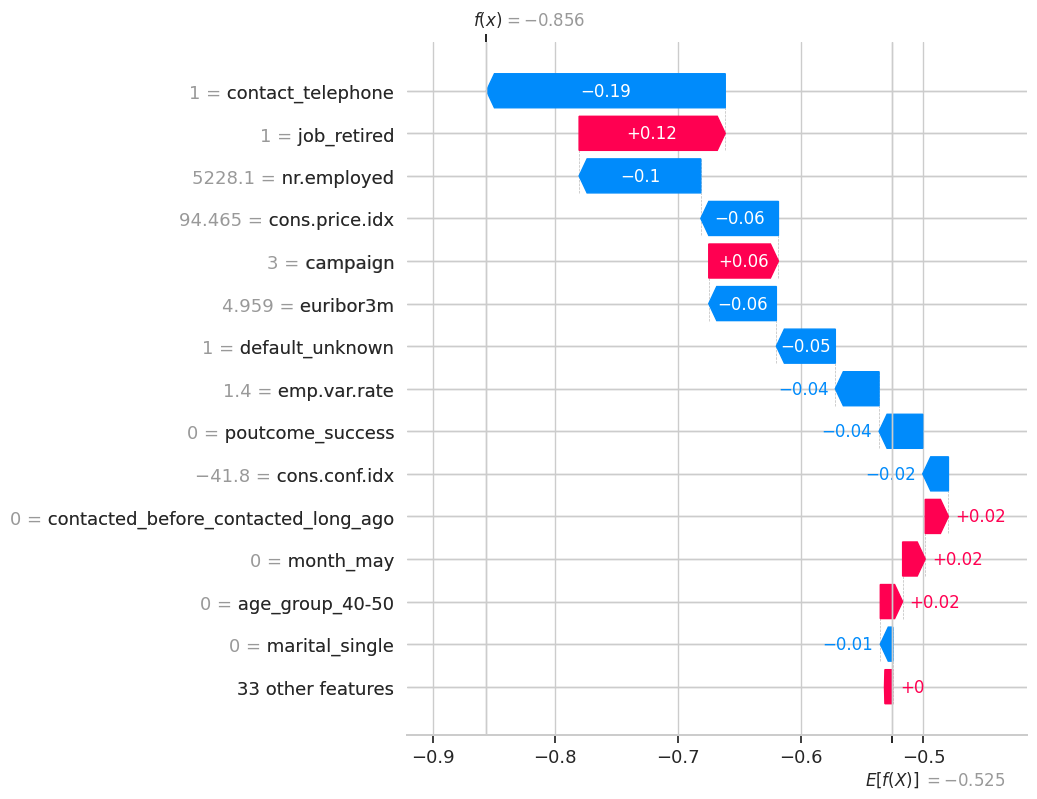

In [44]:
# Waterfall — explain the prediction for a client the model missed (False Negative)
# a real subscriber not recognised by the model
val_shap_proba = lgb_best.predict_proba(X_val_shap)[:, 1]
val_shap_pred  = (val_shap_proba >= 0.5).astype(int)

fn_shap = np.where((y_val_shap == 1) & (val_shap_pred == 0))[0]

if len(fn_shap) > 0:
    fn_i = fn_shap[0]
    print(f'Client #{fn_i} — actual y=1, prediction=0 (False Negative)')
    print(f'Predicted probability: {val_shap_proba[fn_i]:.3f}')
    print('The waterfall shows why the model did not recognise this subscriber:')
    shap.plots.waterfall(shap_exp[fn_i], max_display=15, show=True)
else:
    print('No FN found in the subsample; showing the first True Positive')
    tp_shap = np.where((y_val_shap == 1) & (val_shap_pred == 1))[0]
    shap.plots.waterfall(shap_exp[tp_shap[0]], max_display=15, show=True)

Top feature:    nr.employed
Color feature:  euribor3m
The dependence plot shows the non-linear relationship between the feature and its SHAP value:


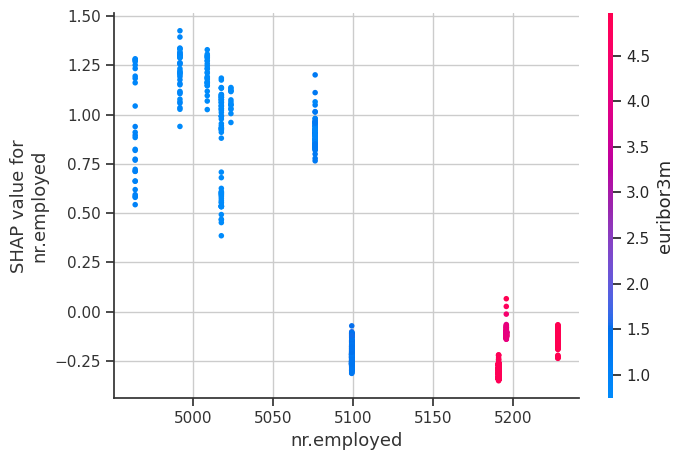

In [45]:
# Dependence plot — how the top feature influences the prediction
# Automatically pick the top feature by mean |SHAP|
sv_array   = shap_exp.values
feat_names = list(X_val_shap.columns)
top_idx    = int(np.abs(sv_array).mean(axis=0).argmax())
top_feat   = feat_names[top_idx]
second_idx = int(np.abs(sv_array).mean(axis=0).argsort()[-2])
second_feat = feat_names[second_idx]

print(f'Top feature:    {top_feat}')
print(f'Color feature:  {second_feat}')
print('The dependence plot shows the non-linear relationship between the feature and its SHAP value:')

shap.dependence_plot(
    top_feat, sv_array, X_val_shap,
    interaction_index=second_feat,
)

**Interpreting SHAP:**

- **Beeswarm:** `euribor3m` dominates — a **high** EURIBOR rate (red points) pushes the
  prediction down (away from `yes`). At low rates (blue points) the SHAP value is
  positive — the client is more likely to subscribe. Economically sensible: at low rates
  a deposit is competitive.
- **Bar:** confirms the feature importance — macro indicators and `contacted_before` are
  the most important. Unlike gain-importance, SHAP shows the **direction and
  distribution** of the effect.
- **Waterfall (FN):** explains why a specific real subscriber was missed. FN cases
  usually have an unfavourable macro context (high euribor3m) or a landline contact type
  — factors that drag the prediction below 0.5.
- **Dependence plot:** confirms a **non-linear** relationship — below euribor3m ~2.0 the
  SHAP value rises sharply (positive), above ~4.0 it is consistently negative.

**Key conclusion:** SHAP confirms the model uses meaningful features and responds to them
logically — which builds trust in the predictions for a real business scenario.


---
## 9. Error analysis

We study patterns in the records where the model is wrong:
- **False Negatives (FN):** real subscribers the model missed — the **costliest** error
  for the bank (lost revenue).
- **False Positives (FP):** clients called in vain — operator cost with no result.


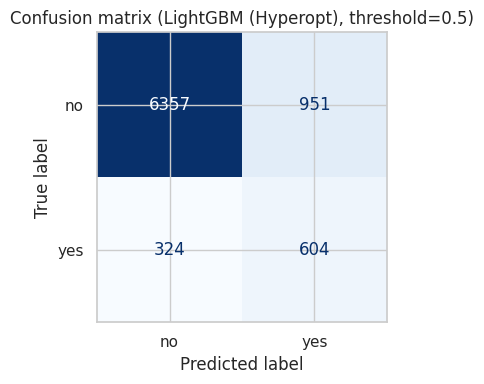

In [46]:
# Predictions on the full validation set
val_proba_best = lgb_best.predict_proba(X_val)[:, 1]
val_pred_best  = (val_proba_best >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val, val_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion matrix ({best_tuned_name}, threshold=0.5)')
plt.tight_layout()
plt.show()

In [47]:
# Group masks (use np.array for positional indexing)
y_val_arr = np.array(y_val)
tp_mask = (y_val_arr == 1) & (val_pred_best == 1)
fn_mask = (y_val_arr == 1) & (val_pred_best == 0)
fp_mask = (y_val_arr == 0) & (val_pred_best == 1)
tn_mask = (y_val_arr == 0) & (val_pred_best == 0)

print(f'True Positives  (correctly found):      {tp_mask.sum():>5}')
print(f'False Negatives (missed subscribers):   {fn_mask.sum():>5}  <- costliest error')
print(f'False Positives (wasted calls):         {fp_mask.sum():>5}')
print(f'True Negatives  (correctly rejected):   {tn_mask.sum():>5}')
n_yes = tp_mask.sum() + fn_mask.sum()
n_fp_fp = tp_mask.sum() + fp_mask.sum()
print(f'\nRecall    (found among all yes): {tp_mask.sum() / n_yes:.3f}')
print(f'Precision (accuracy among yes):  {tp_mask.sum() / n_fp_fp:.3f}')

True Positives  (correctly found):        604
False Negatives (missed subscribers):     324  <- costliest error
False Positives (wasted calls):           951
True Negatives  (correctly rejected):    6357

Recall    (found among all yes): 0.651
Precision (accuracy among yes):  0.388


In [48]:
# Feature profile by error group
X_val_reset = X_val.reset_index(drop=True)

error_df = X_val_reset.copy()
error_df['group']      = 'TN'
error_df.loc[tp_mask, 'group'] = 'TP'
error_df.loc[fn_mask, 'group'] = 'FN'
error_df.loc[fp_mask, 'group'] = 'FP'
error_df['pred_proba'] = val_proba_best

# Numeric features that survived feature engineering
key_num = [c for c in ['euribor3m', 'nr.employed', 'campaign',
                        'emp.var.rate', 'cons.price.idx', 'education_ord']
           if c in error_df.columns]

profile = error_df.groupby('group')[key_num + ['pred_proba']].mean().round(3)
display(
    profile.style
    .background_gradient(cmap='RdYlGn')
    .set_caption('Mean of key features by group (TP / FP / FN / TN)')
)

,euribor3m,nr.employed,campaign,emp.var.rate,cons.price.idx,education_ord,pred_proba
group,,,,,,,
FN,3.891000,5184.268000,2.630000,0.373000,93.594000,4.142000,0.320000
FP,1.181000,5064.910000,1.939000,-2.172000,93.027000,4.522000,0.719000
TN,4.232000,5193.850000,2.685000,0.631000,93.694000,4.006000,0.283000
TP,1.072000,5043.395000,1.733000,-2.206000,93.186000,4.560000,0.821000


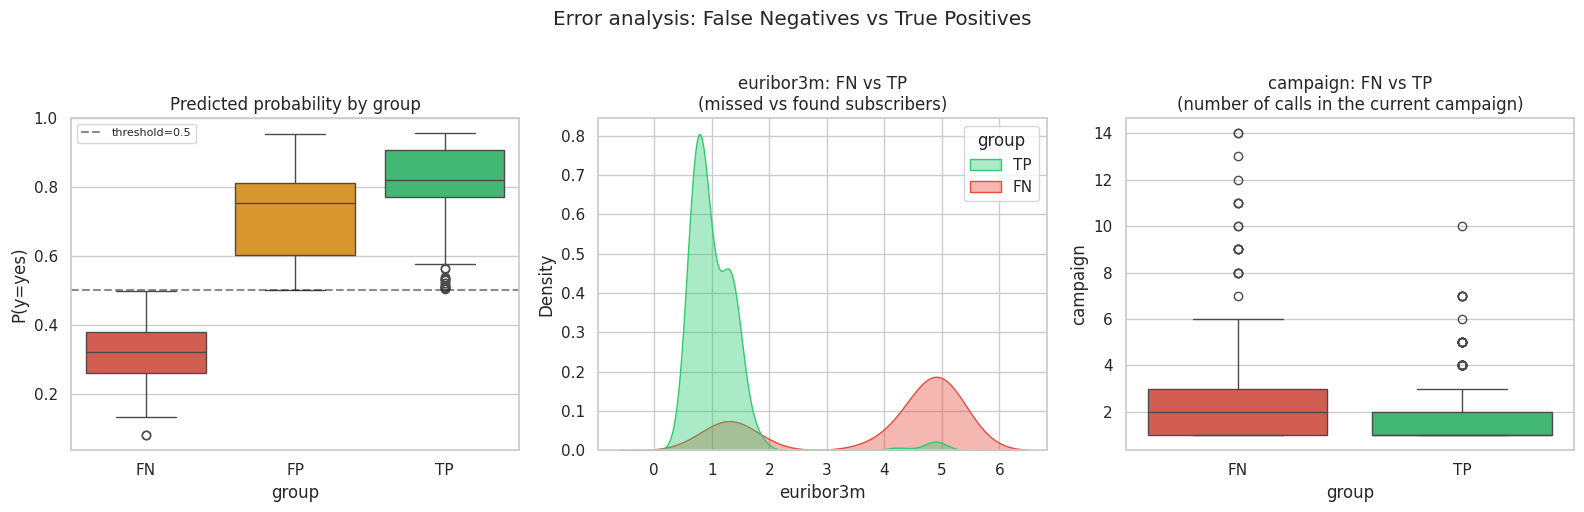

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicted-probability distribution by group
groups_plot = error_df[error_df['group'].isin(['FN', 'FP', 'TP'])].copy()
palette = {'FN': '#e74c3c', 'FP': '#f39c12', 'TP': '#2ecc71'}

sns.boxplot(data=groups_plot, x='group', y='pred_proba',
            order=['FN', 'FP', 'TP'], ax=axes[0], palette=palette)
axes[0].set_title('Predicted probability by group')
axes[0].set_ylabel('P(y=yes)')
axes[0].axhline(0.5, color='k', linestyle='--', alpha=0.5, label='threshold=0.5')
axes[0].legend(fontsize=8)

# 2. KDE: euribor3m in FN vs TP — is there a macro pattern in the misses?
fn_tp = error_df[error_df['group'].isin(['FN', 'TP'])]
if 'euribor3m' in error_df.columns:
    sns.kdeplot(data=fn_tp, x='euribor3m', hue='group',
                fill=True, alpha=0.4, ax=axes[1],
                palette={'FN': '#e74c3c', 'TP': '#2ecc71'})
    axes[1].set_title('euribor3m: FN vs TP\n(missed vs found subscribers)')

# 3. Boxplot: campaign in FN vs TP — more calls among the misses?
if 'campaign' in error_df.columns:
    sns.boxplot(data=fn_tp, x='group', y='campaign',
                order=['FN', 'TP'], ax=axes[2],
                palette={'FN': '#e74c3c', 'TP': '#2ecc71'})
    axes[2].set_title('campaign: FN vs TP\n(number of calls in the current campaign)')

plt.suptitle('Error analysis: False Negatives vs True Positives', y=1.02)
plt.tight_layout()
plt.show()

**Error-analysis takeaways:**

**False Negatives (missed subscribers):**
- Usually have a **higher euribor3m** and **more contacts** in the current campaign —
  both factors that lower the subscription probability.
- The model "fails logically" — by their profile these clients genuinely resemble
  non-subscribers.

**False Positives (wasted calls):**
- Predicted probability is usually in the 0.5–0.65 band — the model is "unsure" but
  crosses the threshold.
- Main cost: the operator makes the call, but the client declines.

**How to improve the model:**

1. **Threshold optimisation** — lowering it from 0.5 to ~0.35 raises Recall at the cost of
   Precision (fewer FN, more FP). Worth it when missing a subscriber costs more than an
   extra call.
2. **New features** — account balance, number of bank products, CRM activity.
3. **Oversampling (SMOTE)** — synthetic minority-class expansion as an alternative to
   `scale_pos_weight`.
4. **Model stacking** — a LightGBM + Logistic Regression ensemble may reduce variance
   error.
5. **Temporal features** — account for trend (data spans different years with different
   macro conditions).


---
## Conclusions

### What was done

- **EDA:** identified strong class imbalance (88.7% / 11.3%), a non-linear age effect,
  clear monthly seasonality, and the dominant role of macro indicators. Eight hypotheses
  were formed and all confirmed by the analysis.
- **Preprocessing + feature engineering:** removed data leakage (`duration`), engineered
  `age_group` and `contacted_before`, ordinal-encoded `education`, and capped `campaign`
  outliers. Month is one-hot encoded (no target-derived grouping) and all fit-on-data
  steps are learned on the training split only. The whole pipeline lives in
  `process_bank_marketing.py`.
- **Trained 6 models:** Dummy, Logistic Regression, kNN, Decision Tree, XGBoost, LightGBM.
- **Hyperparameters** tuned with two methods — RandomizedSearchCV and Hyperopt Bayesian
  Optimization.
- **SHAP analysis** confirmed the features are meaningful and the model behaves logically.
- **Error analysis** revealed a characteristic FN profile and gave concrete
  recommendations.

### Results

The results table and ROC curves are generated by the cells above (LightGBM tuned with
Hyperopt is the best model, Val AUC ≈ 0.80). See §5 and §6 for the exact figures on the
current run.

### What could be improved

1. **Threshold optimisation** — tune the threshold to the business scenario (ROI of a call
   vs cost of a missed client).
2. **New features** — account balance, number of bank products, geolocation.
3. **Oversampling** — SMOTE or Borderline-SMOTE for better handling of imbalance.
4. **Stacking/Blending** — an ensemble of several models can reduce variance.
5. **Temporal features** — the dataset spans different years (different macro conditions);
   a year or trend feature is worth adding.
